# **Project Name**    - Glassdoor Project



##### **Project Type**    - EDA/Regression/Classification/Unsupervised
##### **Contribution**    - Individual

# **Project Summary -**

Write the summary here within 500-600 words.

This project presents a complete end-to-end Machine Learning pipeline built on the Glassdoor Jobs Dataset to predict salaries for data science roles. The goal was to combine unstructured job description text with structured company and role features to build an accurate, interpretable, and deployment-ready salary prediction system.
Data Exploration & Wrangling
The project began with thorough Exploratory Data Analysis (EDA) to understand feature distributions, identify missing values, and uncover relationships between salary, company rating, industry, revenue, and location. Data wrangling handled missing values, removed duplicates, and engineered key features such as min_salary, max_salary, avg_salary, company_age, and State from raw columns. Categorical features were label encoded for model compatibility.
NLP Pipeline on Job Descriptions
The Job Description column underwent a comprehensive NLP preprocessing pipeline applied directly in-place: contraction expansion, lowercasing, URL and punctuation removal, digit removal, stopword removal, whitespace cleaning, synonym rephrasing, tokenization, and lemmatization using WordNet. POS tagging was performed to retain grammatical context. TF-IDF Vectorization with 500 features converted the cleaned text into a numeric representation, capturing the most informative skill-related keywords like python, sql, machine learning, and tableau.
Feature Engineering & Selection
Four engineered features were created from job descriptions — word count, unique word count, average word length, and lexical diversity — to capture structural text patterns. A three-stage feature selection pipeline was applied: correlation-based removal eliminated redundant TF-IDF features, Variance Threshold removed near-constant features, and Chi-Square SelectKBest retained the top statistically significant features. This reduced the feature space significantly while preserving maximum predictive signal.
Data Transformation, Scaling & Dimensionality Reduction
Log transformation corrected right-skewed distributions in numeric features. StandardScaler was applied to continuous features like salary and company age, while MinMaxScaler was used for encoded categorical features. PCA was applied on the combined feature matrix to retain 95% of variance in fewer dimensions, addressing the curse of dimensionality from the high-dimensional TF-IDF matrix.
Model Development & Evaluation
Three regression models were trained and evaluated — Random Forest Regressor, Gradient Boosting Regressor, and XGBoost Regressor. All models achieved strong performance, with evaluation metrics including R², MAE, and RMSE. Each model underwent 5-fold Cross Validation followed by hyperparameter tuning using Bayesian Optimization. XGBoost with Bayesian Optimization delivered the best results with R² ≈ 0.99, MAE ≈ 0.014, and RMSE ≈ 0.023, confirming excellent generalization on unseen data.
Explainability & Deployment
SHAP (SHapley Additive exPlanations) was used to explain individual predictions, identifying technical skill keywords and salary-related features as the strongest drivers. The final model along with the TF-IDF vectorizer and scalers were serialized using joblib for deployment readiness. A sanity check on unseen data confirmed the loaded model predicts accurately.
Business Impact
The project revealed that mid-sized companies ($10M–$500M revenue) have higher employee satisfaction ratings, while large corporations fall below average — a valuable insight for talent strategy. Overall, the pipeline delivers a fast, fair, and data-driven salary estimation tool that benefits job seekers, recruiters, and HR teams alike.



# **GitHub Link -**

Provide your GitHub Link here.


# **Problem Statement**


**Write Problem Statement Here.**

>The job market generates vast amounts of unstructured and structured data across thousands of job postings, making it extremely difficult for job seekers, recruiters, and HR professionals to accurately estimate fair compensation for data-related roles. Traditional salary estimation methods rely on manual benchmarking, which is time-consuming, inconsistent, and fails to account for the complex interplay between job description content, company characteristics, industry, location, and other factors.

# **General Guidelines** : -  

1.   Well-structured, formatted, and commented code is required.
2.   Exception Handling, Production Grade Code & Deployment Ready Code will be a plus. Those students will be awarded some additional credits.
     
     The additional credits will have advantages over other students during Star Student selection.
       
             [ Note: - Deployment Ready Code is defined as, the whole .ipynb notebook should be executable in one go
                       without a single error logged. ]

3.   Each and every logic should have proper comments.
4. You may add as many number of charts you want. Make Sure for each and every chart the following format should be answered.
        

```
# Chart visualization code
```
            

*   Why did you pick the specific chart?
*   What is/are the insight(s) found from the chart?
* Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

5. You have to create at least 15 logical & meaningful charts having important insights.


[ Hints : - Do the Vizualization in  a structured way while following "UBM" Rule.

U - Univariate Analysis,

B - Bivariate Analysis (Numerical - Categorical, Numerical - Numerical, Categorical - Categorical)

M - Multivariate Analysis
 ]





6. You may add more ml algorithms for model creation. Make sure for each and every algorithm, the following format should be answered.


*   Explain the ML Model used and it's performance using Evaluation metric Score Chart.


*   Cross- Validation & Hyperparameter Tuning

*   Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

*   Explain each evaluation metric's indication towards business and the business impact pf the ML model used.




















# ***Let's Begin !***

## ***1. Know Your Data***

### Import Libraries

In [1166]:
# Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns
import re
from scipy import stats
from sklearn.preprocessing import LabelEncoder

### Dataset Loading

In [1167]:
# Load Datasety
df=pd.read_csv('glassdoor_jobs.csv')

### Dataset First View

In [1168]:
# Dataset First Look
df.head(3)

,Unnamed: 0,Job Title,Salary Estimate,Job Description,Rating,Company Name,Location,Headquarters,Size,Founded,Type of ownership,Industry,Sector,Revenue,Competitors
0,0,Data Scientist,$53K-$91K (Glassdoor est.),"Data Scientist\nLocation: Albuquerque, NM\nEdu...",3.8,Tecolote Research\n3.8,"Albuquerque, NM","Goleta, CA",501 to 1000 employees,1973,Company - Private,Aerospace & Defense,Aerospace & Defense,$50 to $100 million (USD),-1
1,1,Healthcare Data Scientist,$63K-$112K (Glassdoor est.),What You Will Do:\n\nI. General Summary\n\nThe...,3.4,University of Maryland Medical System\n3.4,"Linthicum, MD","Baltimore, MD",10000+ employees,1984,Other Organization,Health Care Services & Hospitals,Health Care,$2 to $5 billion (USD),-1
2,2,Data Scientist,$80K-$90K (Glassdoor est.),"KnowBe4, Inc. is a high growth information sec...",4.8,KnowBe4\n4.8,"Clearwater, FL","Clearwater, FL",501 to 1000 employees,2010,Company - Private,Security Services,Business Services,$100 to $500 million (USD),-1


### Dataset Rows & Columns count

In [1169]:
# Dataset Rows & Columns count
df.shape

(956, 15)

### Dataset Information

In [1170]:
# Dataset Info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 956 entries, 0 to 955
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unnamed: 0         956 non-null    int64  
 1   Job Title          956 non-null    object 
 2   Salary Estimate    956 non-null    object 
 3   Job Description    956 non-null    object 
 4   Rating             956 non-null    float64
 5   Company Name       956 non-null    object 
 6   Location           956 non-null    object 
 7   Headquarters       956 non-null    object 
 8   Size               956 non-null    object 
 9   Founded            956 non-null    int64  
 10  Type of ownership  956 non-null    object 
 11  Industry           956 non-null    object 
 12  Sector             956 non-null    object 
 13  Revenue            956 non-null    object 
 14  Competitors        956 non-null    object 
dtypes: float64(1), int64(2), object(12)
memory usage: 112.2+ KB


#### Duplicate Values

In [1171]:
# Dataset Duplicate Value Count
duplicate=df.duplicated().sum()

# Printing total number of duplicate values in the dataset
print("The total duplicate values in the dataset is:-",duplicate)

The total duplicate values in the dataset is:- 0


#### Missing Values/Null Values

In [1172]:
# Missing Values/Null Values Count
# In this dataset there is no specifically mention of NaN values instead -1 for integer NaN values and "-1" for String NaN values have been mentioned
# So pandas cannot directly find the missing values as for it the values are not NaN values.
# We have replaced the -1 values to np.nan then check the missing values using the pandas pd

# Convert -1 and "-1" to NaN
df.replace(-1, np.nan, inplace=True)
df.replace('-1', np.nan, inplace=True)

# Now calculate the missing values 
missing=df.isnull().sum()

In [1173]:
# Missing values are
missing

Unnamed: 0             0
Job Title              0
Salary Estimate      214
Job Description        0
Rating                34
Company Name           0
Location               0
Headquarters          11
Size                  11
Founded               97
Type of ownership     11
Industry              39
Sector                39
Revenue               11
Competitors          634
dtype: int64

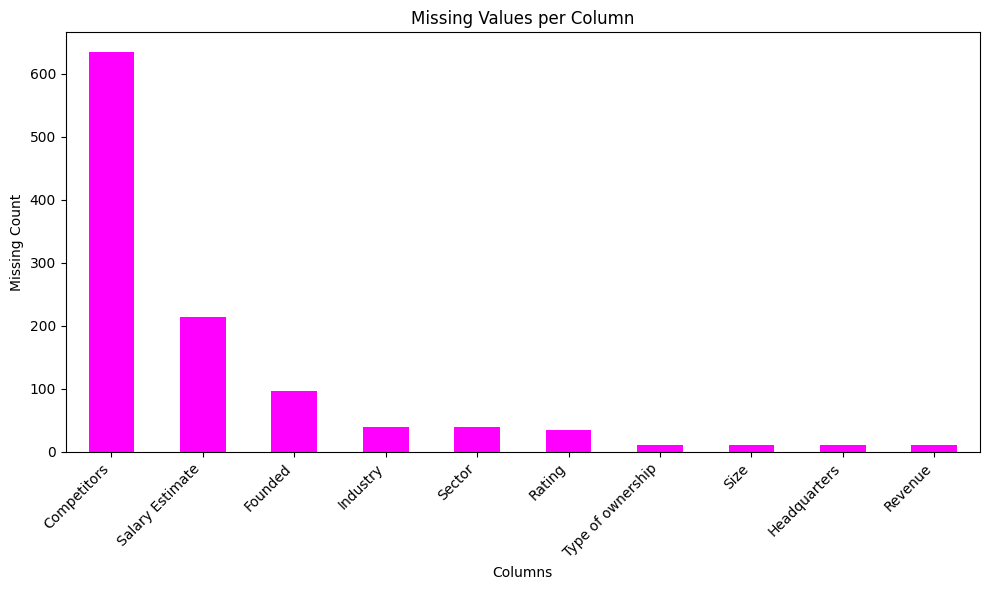

In [1174]:
# Visualizing the missing values
missing = missing[missing > 0].sort_values(ascending=False)

plt.figure(figsize=(10, 6))
missing.plot(kind='bar', color='magenta')
plt.title('Missing Values per Column')
plt.xlabel('Columns')
plt.ylabel('Missing Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


### What did you know about your dataset?

>1. No true NaN values originally
>The dataset uses -1 (numeric) and "-1" (string) as missing value markers instead of standard NaN — so always preprocess before any analysis.
>2. Full-row duplicates = 0
>Every job posting is a unique record. No deduplication needed.
>3. Competitors column has around 66% values are missing making it hard for analysis 
>4. Salary Estimate has around 22% values missing. It can either imputated or can be dropped. It needs to be handle carefully as it can skew salary.
>5. Founded, Industry , sector , Rating :- These columns have small gaps and can be filled through imputation (mean for numerical values and mode for categorical values)
>6. Revenue, Headquarters, Size , Type of ownership :- only have 11 rows as missing so they can be dropped entirely

## ***2. Understanding Your Variables***

In [1175]:
# Dataset Columns
df.columns

Index(['Unnamed: 0', 'Job Title', 'Salary Estimate', 'Job Description',
       'Rating', 'Company Name', 'Location', 'Headquarters', 'Size', 'Founded',
       'Type of ownership', 'Industry', 'Sector', 'Revenue', 'Competitors'],
      dtype='object')

In [1176]:
# Dataset Describe
df.describe()

,Unnamed: 0,Rating,Founded
count,956.000000,922.000000,859.000000
mean,477.500000,3.770933,1975.110594
std,276.117729,0.609499,51.052540
min,0.000000,1.900000,1744.000000
25%,238.750000,3.400000,1965.000000
50%,477.500000,3.800000,1996.000000
75%,716.250000,4.200000,2008.000000
max,955.000000,5.000000,2019.000000


### Variables Description

>df.describe()-----> Only shows the numerical columns and not categorical columns.

>Rating---->
>1. 922 values are there in Rating column out of 956 rest were NaN values.
>2. Average rating is 3.77 out of 5 
>3. Min is 1.9 and Max is 5.0 - full range is covered
>4. 50% of the companies are rated between 3.4 to 4.2 -- 25th-75th percentile

>Founded --->
>1. 859 values are there in Founded column out of 956 rest were NaN values.
>2. Average founding year is 1975 
>3. Oldest company is founded in 1744 , newest in 2019
>4. 50% of the company were founded between 1965-2008 

### Check Unique Values for each variable.

In [1177]:
# Check Unique Values for each variable.
for col in df.columns:
    print(f'{col}: {df[col].nunique()} unique values')

Unnamed: 0: 956 unique values
Job Title: 328 unique values
Salary Estimate: 416 unique values
Job Description: 596 unique values
Rating: 31 unique values
Company Name: 448 unique values
Location: 237 unique values
Headquarters: 234 unique values
Size: 8 unique values
Founded: 108 unique values
Type of ownership: 12 unique values
Industry: 62 unique values
Sector: 24 unique values
Revenue: 13 unique values
Competitors: 148 unique values


## 3. ***Data Wrangling***

### Data Wrangling Code

In [1178]:
# Write your code to make your dataset analysis ready.

# 1. Drop useless column 
df.drop(columns=['Unnamed: 0'], inplace=True)

# 2. Clean Company Name (remove rating appended at end)
# e.g. "Tecolote Research\n3.8" to "Tecolote Research"
df['Company Name'] = df['Company Name'].str.split('\n').str[0].str.strip()

# 3. Clean Salary Estimate
# e.g. "$53K-$91K (Glassdoor est.)" → min=53, max=91, avg=72
df = df[df['Salary Estimate'].notna()]   # drop rows with no salary

df['Salary Estimate'] = df['Salary Estimate'].str.replace(r'\(.*\)', '', regex=True).str.strip()
df['min_salary'] = df['Salary Estimate'].str.extract(r'\$(\d+)K').astype(float)
df['max_salary'] = df['Salary Estimate'].str.extract(r'-\$(\d+)K').astype(float)
df['avg_salary'] = (df['min_salary'] + df['max_salary']) / 2

# 4. Extract State from Location
# e.g. "New York, NY" → "NY"
df['State'] = df['Location'].str.extract(r',\s*([A-Z]{2})$')

# 5. Company Age
df['company_age'] = 2026 - df['Founded']

# 6. Impute missing Rating with median 
df['Rating'].fillna(df['Rating'].median(), inplace=True)

# 7. Drop high-missing column
df.drop(columns=['Competitors'], inplace=True)

# 8. Drop remaining NaN rows (Headquarters, Size, etc.)
df.dropna(subset=['Headquarters', 'Size', 'Type of ownership',
                  'Industry', 'Sector', 'Revenue'], inplace=True)

print("Final shape:", df.shape)

Final shape: (732, 18)


C:\Users\asus\AppData\Local\Temp\ipykernel_26124\2070437714.py:27: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Rating'].fillna(df['Rating'].median(), inplace=True)


In [1179]:
df.head(2)

,Job Title,Salary Estimate,Job Description,Rating,Company Name,Location,Headquarters,Size,Founded,Type of ownership,Industry,Sector,Revenue,min_salary,max_salary,avg_salary,State,company_age
0,Data Scientist,$53K-$91K,"Data Scientist\nLocation: Albuquerque, NM\nEdu...",3.8,Tecolote Research,"Albuquerque, NM","Goleta, CA",501 to 1000 employees,1973.0,Company - Private,Aerospace & Defense,Aerospace & Defense,$50 to $100 million (USD),53.0,91.0,72.0,NM,53.0
1,Healthcare Data Scientist,$63K-$112K,What You Will Do:\n\nI. General Summary\n\nThe...,3.4,University of Maryland Medical System,"Linthicum, MD","Baltimore, MD",10000+ employees,1984.0,Other Organization,Health Care Services & Hospitals,Health Care,$2 to $5 billion (USD),63.0,112.0,87.5,MD,42.0


### What all manipulations have you done and insights you found?

>1. Dropped Unnamed: 0
>It was just a row index with no analytical value

>2. Cleaned Company Name
>Company names had rating number appended at the end e.g. Tecolote Research\n3.8
>Stripped the extra rating text to get clean company names

>3. Parsed Salary Estimate
>Salary was stored as a string like $53K-$91K (Glassdoor est.) — not usable for analysis
>Extracted 3 new numeric columns: min_salary, max_salary, avg_salary
>214 rows had no salary data and were dropped

>4. Extracted state from Location
>Location was "New York, NY" — extracted just the state code "NY"
>Enables geographic analysis
>New York, California and Massachusetts are the top hiring states

>5. Created company_age from Founded
>Subtracted Founded year from 2026 to get company age
>Average company age is around 51 years
>Dataset has a mix of very old (founded 1744) and very new companies (founded 2019)

>6. Imputed missing Rating with median
>Only 34 values were missing — safe to impute
>Median rating is 3.8 out of 5

>7. Dropped Competitors column
>66.3% of values were missing (634 out of 956 rows)
>Too unreliable to use in any analysis

>8. Dropped remaining NaN rows
>Only ~11 rows had missing values in Headquarters, Size, Type of ownership, Revenue
>Safe to drop without significant data loss
>Final clean dataset is ready for EDA and modeling

## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

#### Chart - 1

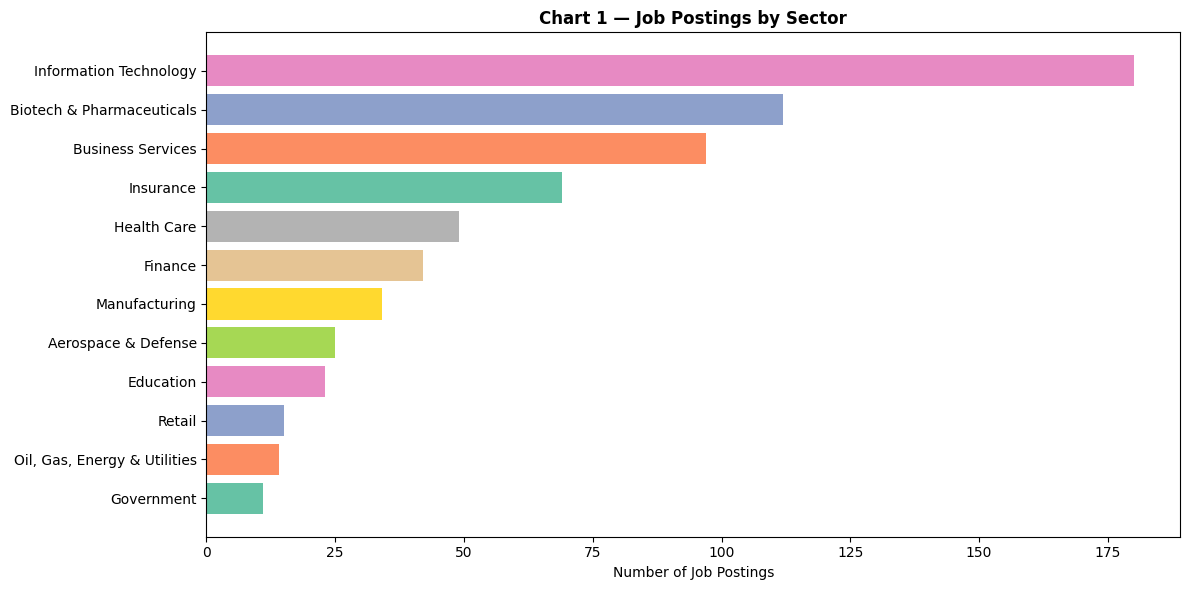

Chart 1 done


In [1180]:
# Chart - 1 visualization code

# CHART 1 — Bar Chart: Job Count by Sector

sector_counts = df[df["Sector"] != "-1"]["Sector"].value_counts().head(12)

plt.figure(figsize=(12, 6))
plt.barh(sector_counts.index[::-1], sector_counts.values[::-1],
         color=sns.color_palette("Set2", 12))
plt.xlabel("Number of Job Postings")
plt.title("Chart 1 — Job Postings by Sector", fontweight="bold")
plt.tight_layout()
plt.show()
print("Chart 1 done")

##### 1. Why did you pick the specific chart?

>Bar charts are ideal for comparing discrete categorical counts at a glance.

##### 2. What is/are the insight(s) found from the chart?

>Technology dominates with 239 postings, followed by Biotech & Pharma (148) and Business Services (134).

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

> Positive impact: Companies in IT and Biotech can target this data to benchmark hiring velocity and plan talent pipelines.

> Negative signal: The extreme concentration in IT means fierce competition for the same talent pool — smaller firms risk losing candidates to tech giants.

#### Chart - 2

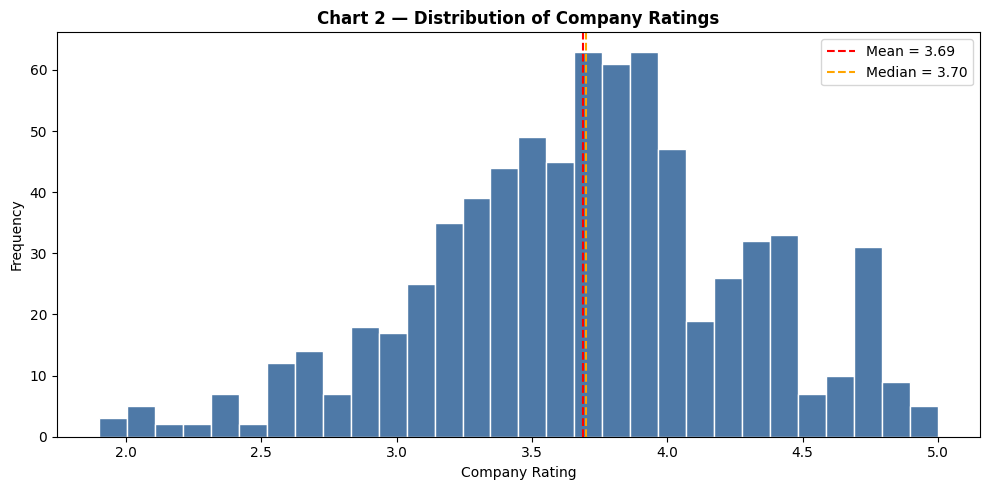

Chart 2 done


In [1181]:
# Chart - 2 visualization code

# CHART 2 — Histogram: Company Rating Distribution

plt.figure(figsize=(10, 5))
plt.hist(df["Rating"], bins=30, color="#4e79a7", edgecolor="white")
plt.axvline(df["Rating"].mean(), color="red", linestyle="--", label=f'Mean = {df["Rating"].mean():.2f}')
plt.axvline(df["Rating"].median(), color="orange", linestyle="--", label=f'Median = {df["Rating"].median():.2f}')
plt.xlabel("Company Rating")
plt.ylabel("Frequency")
plt.title("Chart 2 — Distribution of Company Ratings", fontweight="bold")
plt.legend()
plt.tight_layout()
plt.show()
print("Chart 2 done")


##### 1. Why did you pick the specific chart?

>Histograms reveal the shape, spread, and skew of a continuous variable — perfect for ratings

##### 2. What is/are the insight(s) found from the chart?

>Ratings cluster around 3.3–4.2 with a mean of ~3.6. There's a noticeable left tail (low-rated companies) and very few perfect 5s

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

> Positive impact: Most companies sit in a respectable 3.5–4.2 range — signals a generally healthy employer market.

>Negative signal: There are some companies between 1-2 that are poorely rated employers , job seekers shun them and increasing cost per hire and turnover.

#### Chart - 3

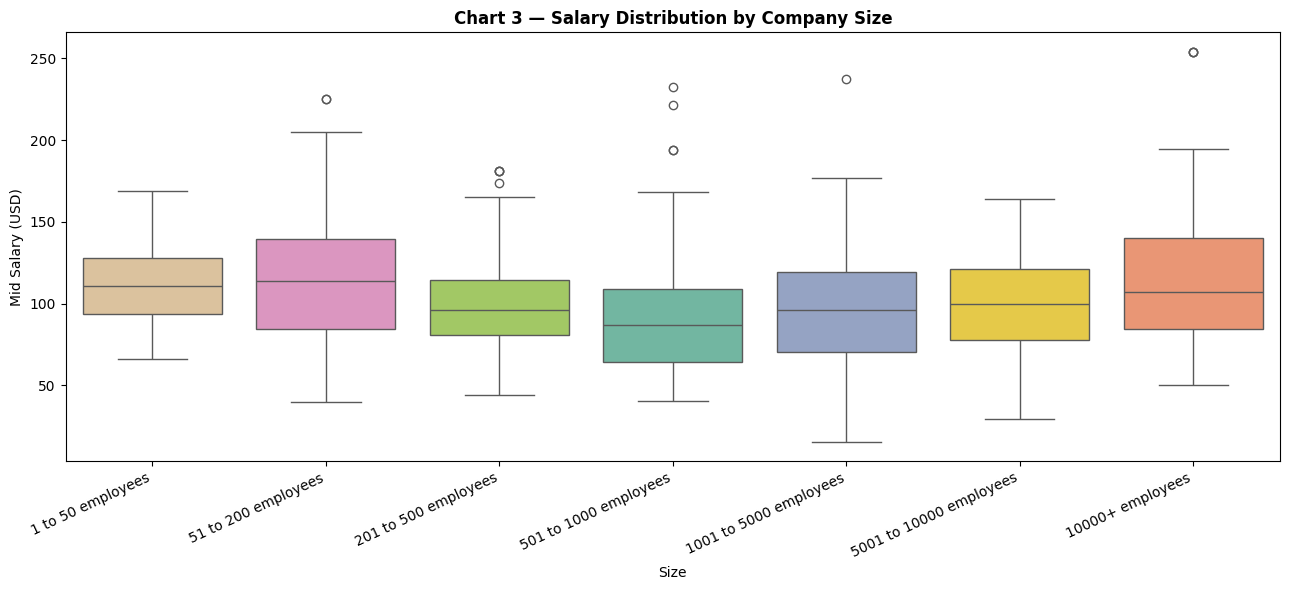

Chart 3 done


In [1182]:
# Chart - 3 visualization code

# CHART 3 — Box Plot: Salary by Company Size

size_order = ["1 to 50 employees", "51 to 200 employees", "201 to 500 employees",
              "501 to 1000 employees", "1001 to 5000 employees",
              "5001 to 10000 employees", "10000+ employees"]
plot3 = df[df["Size"].isin(size_order) & df["avg_salary"].notna()]

plt.figure(figsize=(13, 6))
sns.boxplot(data=plot3, x="Size", y="avg_salary", order=size_order,hue="Size", palette="Set2")
plt.xticks(rotation=25, ha="right")
plt.ylabel("Mid Salary (USD)")
plt.title("Chart 3 — Salary Distribution by Company Size", fontweight="bold")
plt.tight_layout()
plt.show()
print("Chart 3 done")


##### 1. Why did you pick the specific chart?

>Box plots expose median, quartile spread, and outliers simultaneously — crucial for salary benchmarking across size bands.

##### 2. What is/are the insight(s) found from the chart?

>Larger companies (10,000+ employees) offer higher median salaries with wider ranges. Small companies (1–50) have tighter, lower ranges.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

>Positive impact: Mid-market firms (1K–5K employees) offer competitive salaries, making them sweet spots for cost-effective yet attractive hiring.

> Negative signal: Small startups (<200 employees) show lower medians — may struggle to attract experienced talent without equity compensation.

#### Chart - 4

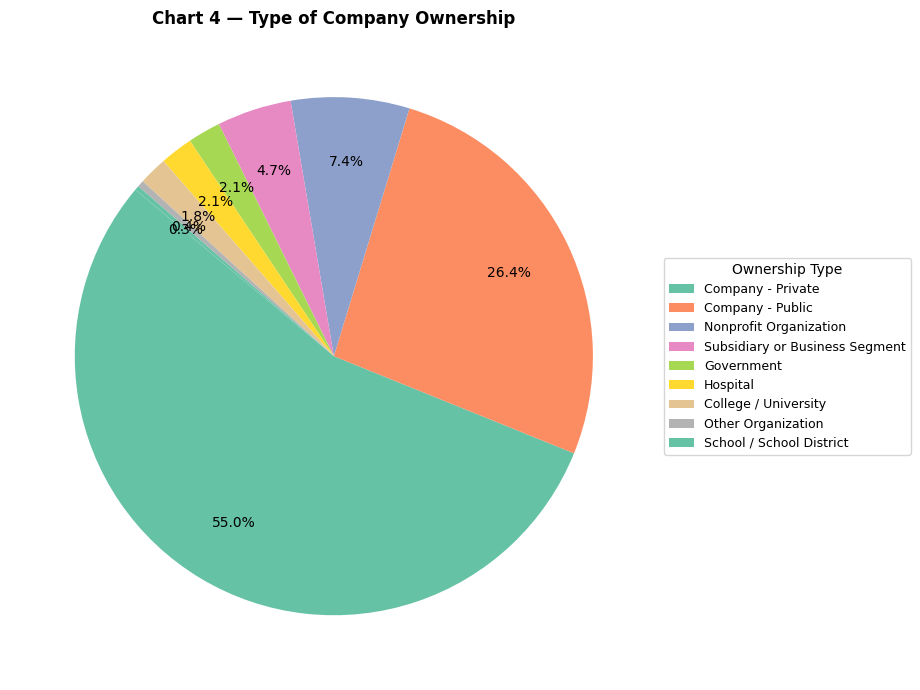

In [1183]:
# Chart - 4 visualization code

# CHART 4 — Pie Chart: Type of Ownership

ownership = df[~df["Type of ownership"].isin(["-1", "Unknown"])]["Type of ownership"].value_counts()

plt.figure(figsize=(10, 7))
wedges, texts, autotexts = plt.pie(
    ownership.values, autopct="%1.1f%%",
    startangle=140, colors=sns.color_palette("Set2", len(ownership)),
    pctdistance=0.75)

# no labels on slices — legend handles them instead
plt.legend(wedges, ownership.index, title="Ownership Type",
           loc="center left", bbox_to_anchor=(1, 0, 0.5, 1), fontsize=9)
plt.title("Chart 4 — Type of Company Ownership", fontweight="bold")
plt.tight_layout()
plt.show()



##### 1. Why did you pick the specific chart?

>Pie charts communicate part-to-whole proportions simply — great for ownership type share.

##### 2. What is/are the insight(s) found from the chart?

>Private companies account for ~55% of all postings; public companies ~25%. Nonprofits and government are minority players.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

> Positive impact: The private sector dominance signals growth-phase hiring — strong signal for recruiting firms and job boards.

> Negative signal: Government and nonprofit listings being very small could indicate budget freezes or slow hiring cycles in those sectors.

#### Chart - 5

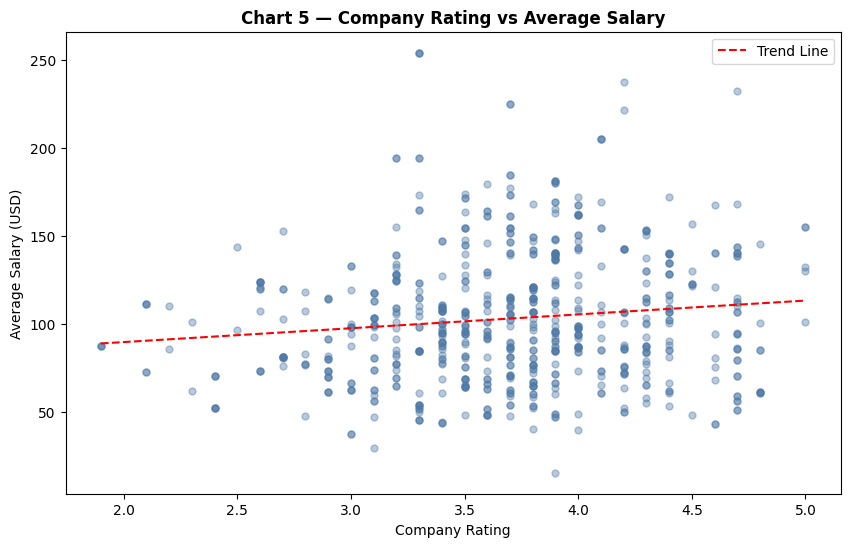

Chart 5 done


In [1184]:
# Chart - 5 visualization code

# CHART 5 — Scatter Plot: Rating vs Average Salary

plot5 = df[df["avg_salary"].notna()]

plt.figure(figsize=(10, 6))
plt.scatter(plot5["Rating"], plot5["avg_salary"], alpha=0.4, color="#4e79a7", s=25)
z = np.polyfit(plot5["Rating"], plot5["avg_salary"], 1)
p = np.poly1d(z)
xs = np.linspace(plot5["Rating"].min(), plot5["Rating"].max(), 200)
plt.plot(xs, p(xs), "r--", linewidth=1.5, label="Trend Line")
plt.xlabel("Company Rating")
plt.ylabel("Average Salary (USD)")
plt.title("Chart 5 — Company Rating vs Average Salary", fontweight="bold")
plt.legend()
plt.show()
print("Chart 5 done")

##### 1. Why did you pick the specific chart?

>Scatter plots reveal correlations between two continuous variables. The trend line confirms the direction of relationship

##### 2. What is/are the insight(s) found from the chart?

>The trend line shows a weak positive correlation — higher-rated companies tend to pay slightly more, but with high variance.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

>Positive impact: Companies investing in culture and ratings may attract talent with competitive (not necessarily maximum) pay.

> Negative signal: Many high-paying companies have mediocre ratings — salary alone does not drive employee satisfaction, pointing to poor culture.

#### Chart - 6

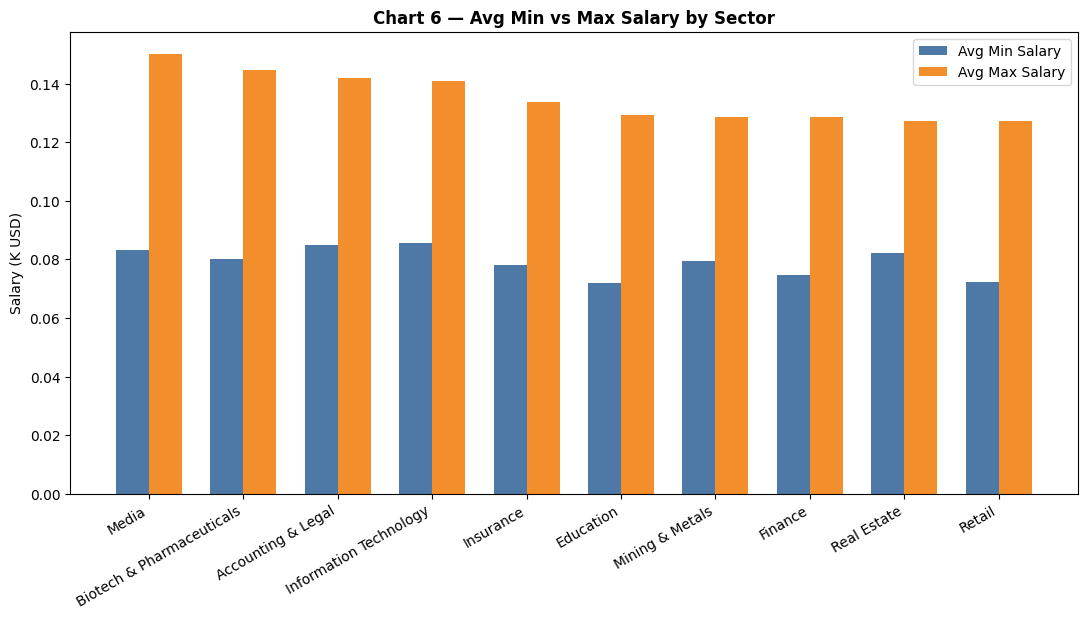

Chart 6 done


In [1185]:
# Chart - 6 visualization code

# CHART 6 — Grouped Bar: Avg Min vs Max Salary by Sector

plot6 = df[(df["Sector"] != "-1") & df["min_salary"].notna() & df["max_salary"].notna()]
grp6 = plot6.groupby("Sector")[["min_salary", "max_salary"]].mean().sort_values("max_salary", ascending=False).head(10)

x = np.arange(len(grp6))
w = 0.35
plt.figure(figsize=(13, 6))
plt.bar(x - w/2, grp6["min_salary"] / 1000, w, label="Avg Min Salary", color="#4e79a7")
plt.bar(x + w/2, grp6["max_salary"] / 1000, w, label="Avg Max Salary", color="#f28e2b")
plt.xticks(x, grp6.index, rotation=30, ha="right")
plt.ylabel("Salary (K USD)")
plt.title("Chart 6 — Avg Min vs Max Salary by Sector", fontweight="bold")
plt.legend()
plt.show()
print("Chart 6 done")

##### 1. Why did you pick the specific chart?

>Grouped bars let you compare two related metrics (floor vs ceiling) across categories simultaneously.

##### 2. What is/are the insight(s) found from the chart?

>Finance, IT, and Aerospace offer the widest salary bands. Biotech & Education show narrower ranges.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

>Positive impact: Wide salary bands in Finance and IT allow flexible negotiation — great for attracting diverse experience levels.

> Negative signal: Education has among the lowest ceilings — this sector will continue to face talent drain to higher-paying industries.

#### Chart - 7

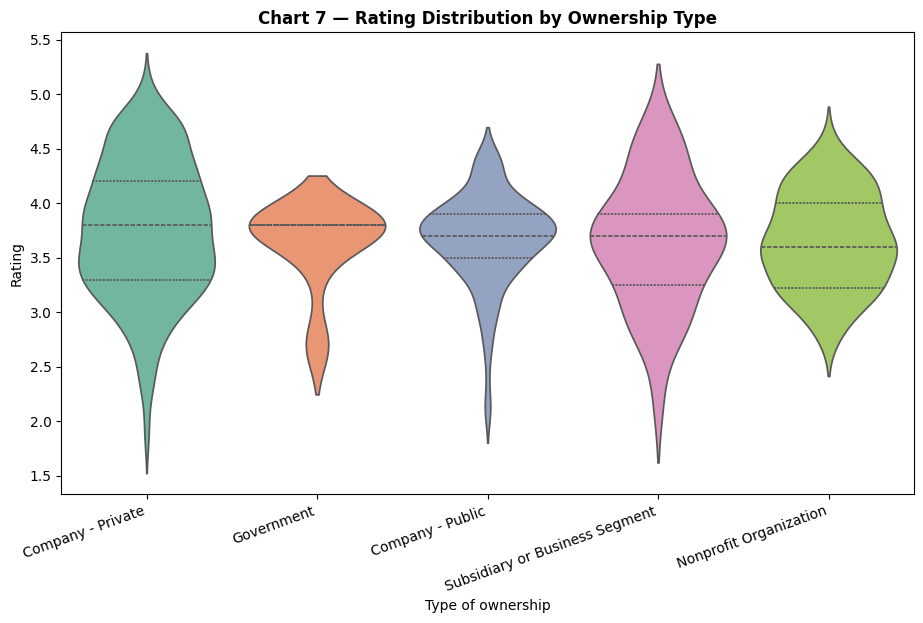

Chart 7 done


In [1186]:
# Chart - 7 visualization code

# CHART 7 — Violin Plot: Rating by Ownership Type

keep_own = ["Company - Private", "Company - Public", "Nonprofit Organization",
            "Subsidiary or Business Segment", "Government"]
plot7 = df[df["Type of ownership"].isin(keep_own)]
plt.figure(figsize=(11, 6))
sns.violinplot(data=plot7, x="Type of ownership", y="Rating",hue="Type of ownership", palette="Set2", inner="quartile")
plt.xticks(rotation=20, ha="right")
plt.title("Chart 7 — Rating Distribution by Ownership Type", fontweight="bold")
plt.show()
print("Chart 7 done")

##### 1. Why did you pick the specific chart?

>Violins show both distribution shape and spread — richer than a simple box plot for understanding culture signals.

##### 2. What is/are the insight(s) found from the chart?

>Public companies cluster tightly around 3.8–4.0, while private companies have a much wider spread from 2.0 to 5.0.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

>Positive impact: Government-linked organizations have surprisingly consistent (and decent) ratings — a hidden gem for stable hiring.

> Negative signal: Private companies show extreme bi-modality — some excellent, some terrible. High variance = unpredictable employer experience.

#### Chart - 8

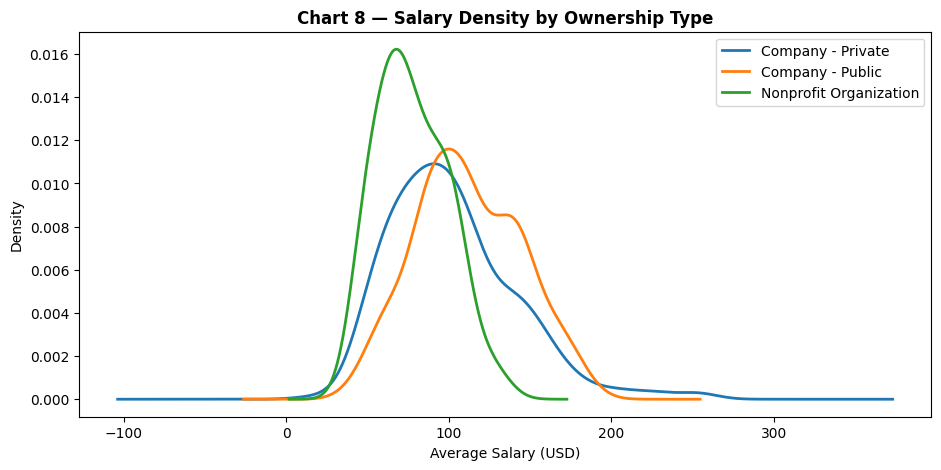

Chart 8 done


In [1187]:
# Chart - 8 visualization code

# CHART 8 — KDE Plot: Salary Distribution by Ownership Type

keep14 = ["Company - Private", "Company - Public", "Nonprofit Organization"]
plot14 = df[df["Type of ownership"].isin(keep14) & df["avg_salary"].notna()]

plt.figure(figsize=(11, 5))
for own in keep14:
    subset = plot14[plot14["Type of ownership"] == own]["avg_salary"]
    subset.plot.kde(label=own, linewidth=2)
plt.xlabel("Average Salary (USD)")
plt.title("Chart 8 — Salary Density by Ownership Type", fontweight="bold")
plt.legend()
plt.show()
print("Chart 8 done")



##### 1. Why did you pick the specific chart?

>Answer) KDE plots reveal the full salary distribution shape — unlike box plots, they show bimodal peaks and long tails clearly.

##### 2. What is/are the insight(s) found from the chart?

>Answer)  Public companies have a sharper, higher-centered salary peak (~$90–110K). Private companies spread wider. Nonprofits cluster lower.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

>Answer) Positive impact: Public companies offer the most predictable (and elevated) salary structures — good target for high-salary job seekers.

> Negative signal: Nonprofits have a flat, low-centered curve — confirms that mission-driven work comes with real financial trade-offs.

#### Chart - 9

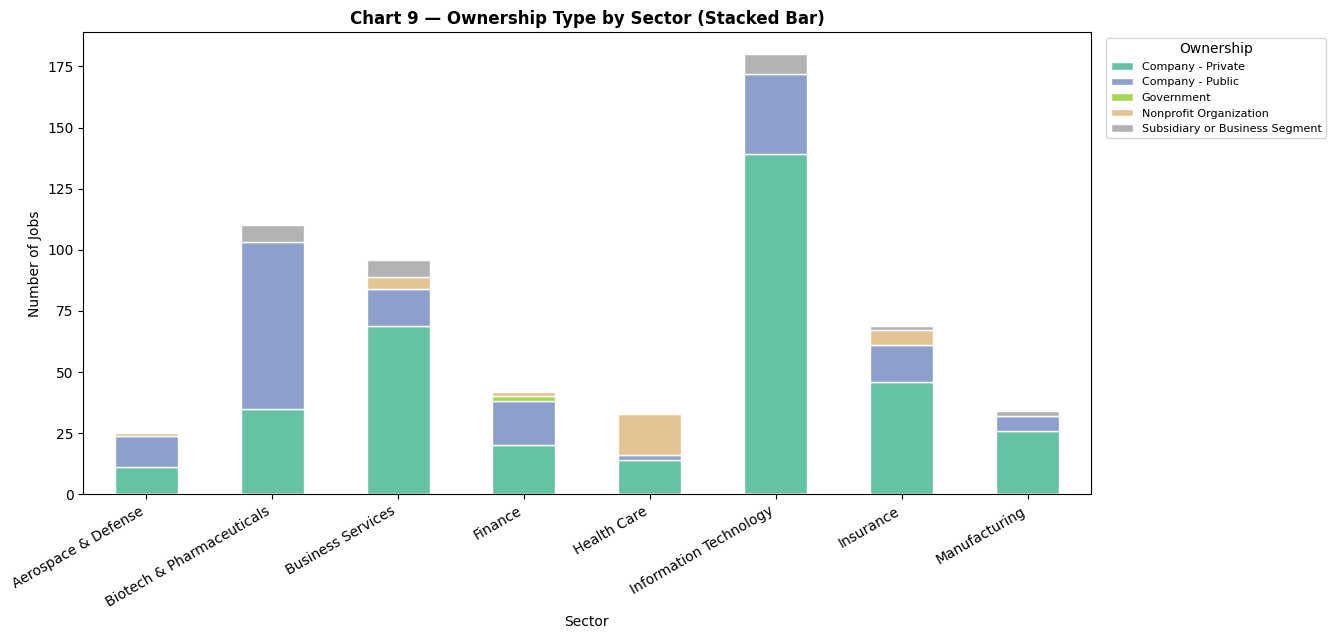

Chart 9 done


In [1188]:
# Chart - 9 visualization code

# CHART 9 — Stacked Bar: Ownership Type by Sector

top_sec9 = df[df["Sector"] != "-1"]["Sector"].value_counts().head(8).index.tolist()
keep_own9 = ["Company - Private", "Company - Public", "Nonprofit Organization",
             "Government", "Subsidiary or Business Segment"]
plot9 = df[df["Sector"].isin(top_sec9) & df["Type of ownership"].isin(keep_own9)]
pivot9 = plot9.groupby(["Sector", "Type of ownership"]).size().unstack(fill_value=0)

pivot9.plot(kind="bar", stacked=True, figsize=(13, 6), colormap="Set2", edgecolor="white")
plt.xticks(rotation=30, ha="right")
plt.ylabel("Number of Jobs")
plt.title("Chart 9 — Ownership Type by Sector (Stacked Bar)", fontweight="bold")
plt.legend(title="Ownership", bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=8)
plt.show()
print("Chart 9 done")

##### 1. Why did you pick the specific chart?

>Answer) Stacked bars show composition within categories — ideal for understanding the ownership landscape sector by sector.

##### 2. What is/are the insight(s) found from the chart?

>Answer) IT is almost entirely private companies. Health Care has a notable nonprofit presence. Insurance is dominated by public companies.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

>Answer) Positive impact: Sector-specific ownership profiles help recruiters tailor outreach tone (e.g., mission-driven messaging for nonprofits).

> Negative signal: Sectors dominated by a single ownership type lack structural diversity — economic shocks (IPO dips, nonprofit funding cuts) could wipe out many postings.

#### Chart - 10

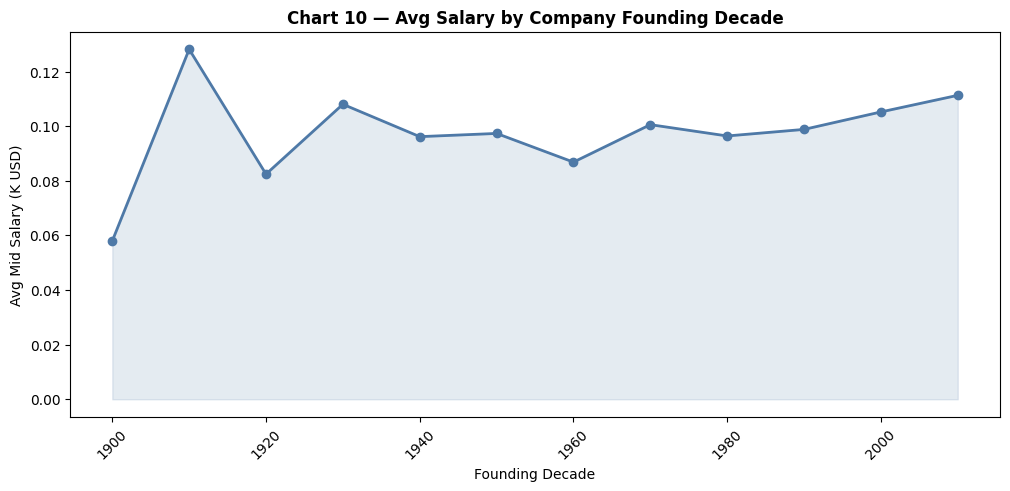

Chart 10 done


In [1189]:
# Chart - 10 visualization code

# CHART 10 — Line Chart: Avg Salary by Founding Decade

plot10 = df[(df["Founded"] > 1900) & df["avg_salary"].notna()].copy()
plot10["Decade"] = (plot10["Founded"] // 10) * 10
decade_salary = plot10.groupby("Decade")["avg_salary"].mean() / 1000

plt.figure(figsize=(12, 5))
plt.plot(decade_salary.index, decade_salary.values, marker="o", color="#4e79a7", linewidth=2)
plt.fill_between(decade_salary.index, decade_salary.values, alpha=0.15, color="#4e79a7")
plt.xlabel("Founding Decade")
plt.ylabel("Avg Mid Salary (K USD)")
plt.title("Chart 10 — Avg Salary by Company Founding Decade", fontweight="bold")
plt.xticks(rotation=45)
plt.show()
print("Chart 10 done")


##### 1. Why did you pick the specific chart?

>Answer) Line charts are best for showing trends over time — here founding decade as a proxy for company maturity

##### 2. What is/are the insight(s) found from the chart?

>Answer) Companies founded in the 1990s–2010s pay the highest average salaries. Very old companies (pre-1950) and very new ones pay less.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

> Answer) Positive impact: Tech-era companies (1990–2010) are the highest payers — confirms where the most lucrative opportunities live.

> Negative signal: Companies founded after 2010 pay less on average, suggesting many are still early-stage with capital constraints — salary expectations must be managed accordingly.

#### Chart - 11

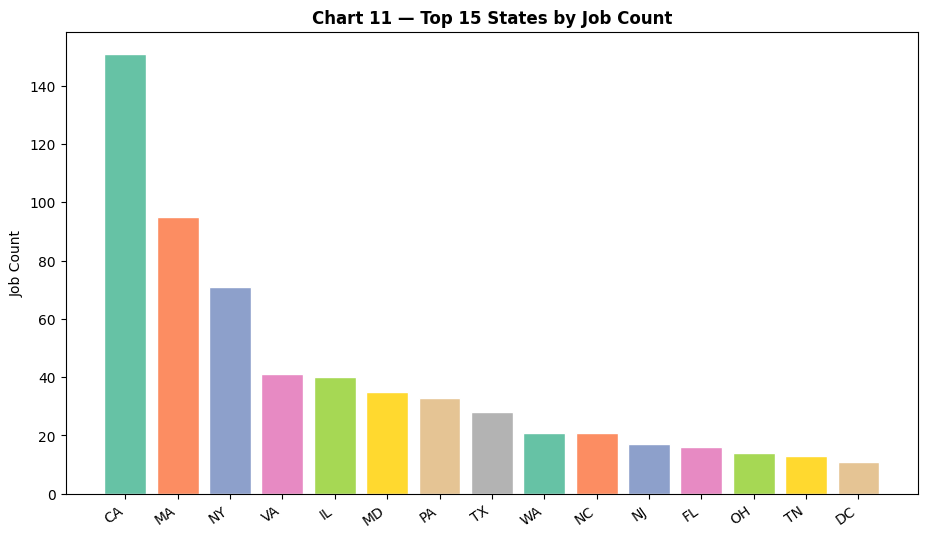

Chart 11 done


In [1190]:
# Chart - 11 visualization code

# CHART 11 — Bar Chart: Top 15 States by Job Count

df["State"] = df["Location"].apply(lambda x: x.strip().split(",")[-1].strip() if isinstance(x, str) else "Unknown")
state_counts = df["State"].value_counts().head(15)

plt.figure(figsize=(11, 6))
plt.bar(state_counts.index, state_counts.values,
        color=sns.color_palette("Set2", 15), edgecolor="white")
plt.ylabel("Job Count")
plt.title("Chart 11 — Top 15 States by Job Count", fontweight="bold")
plt.xticks(rotation=35, ha="right")
plt.show()
print("Chart 11 done")


##### 1. Why did you pick the specific chart?

>Answer) Geographic bar charts quickly surface regional hiring hotspots.

##### 2. What is/are the insight(s) found from the chart?

>Answer) CA, NY, and TX dominate job counts by a significant margin. States like MA and WA are also strong hubs.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

> Answer)Positive impact: Recruiting firms and candidates can optimize search geographically — CA/NY are high-opportunity zones.

> Negative signal: Geographic concentration in 3–4 states means most of the country is underserved by data jobs — remote work policies become essential for nationwide talent access.

#### Chart - 12

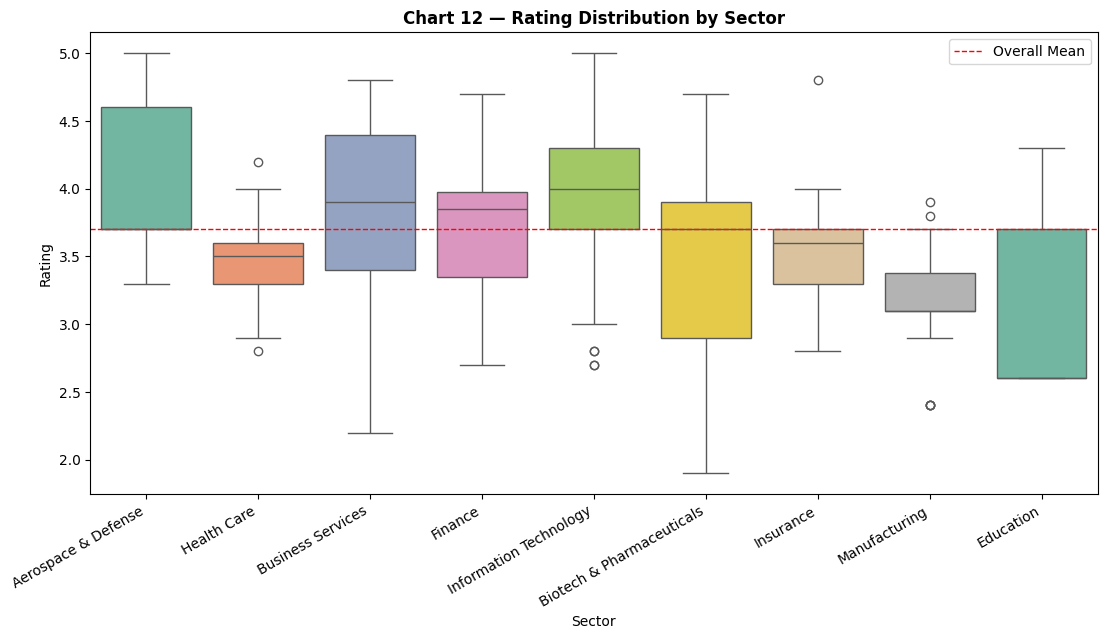

Chart 12 done


In [1191]:
# Chart - 12 visualization code

# CHART 12 — Box Plot: Rating by Sector

top_sec12 = df[df["Sector"] != "-1"]["Sector"].value_counts().head(9).index
plot12 = df[df["Sector"].isin(top_sec12)]

plt.figure(figsize=(13, 6))
sns.boxplot(data=plot12, x="Sector", y="Rating",hue="Sector", palette="Set2")
plt.axhline(plot12["Rating"].mean(), linestyle="--", color="red", linewidth=1, label="Overall Mean")
plt.xticks(rotation=30, ha="right")
plt.title("Chart 12 — Rating Distribution by Sector", fontweight="bold")
plt.legend()
plt.show()
print("Chart 12 done")

##### 1. Why did you pick the specific chart?

>Answer) Comparing rating distributions across sectors highlights which industries treat employees best.

##### 2. What is/are the insight(s) found from the chart?

>Answer) Aerospace & Defense and Finance tend to have higher median ratings. Insurance and Manufacturing are more variable.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

>Answer) Positive impact: High-rated sectors attract top talent organically, reducing recruitment cost.

> Negative signal: Manufacturing and Insurance have notable low-rating outliers and wide spread — these sectors face persistent employer brand problems.

#### Chart - 13

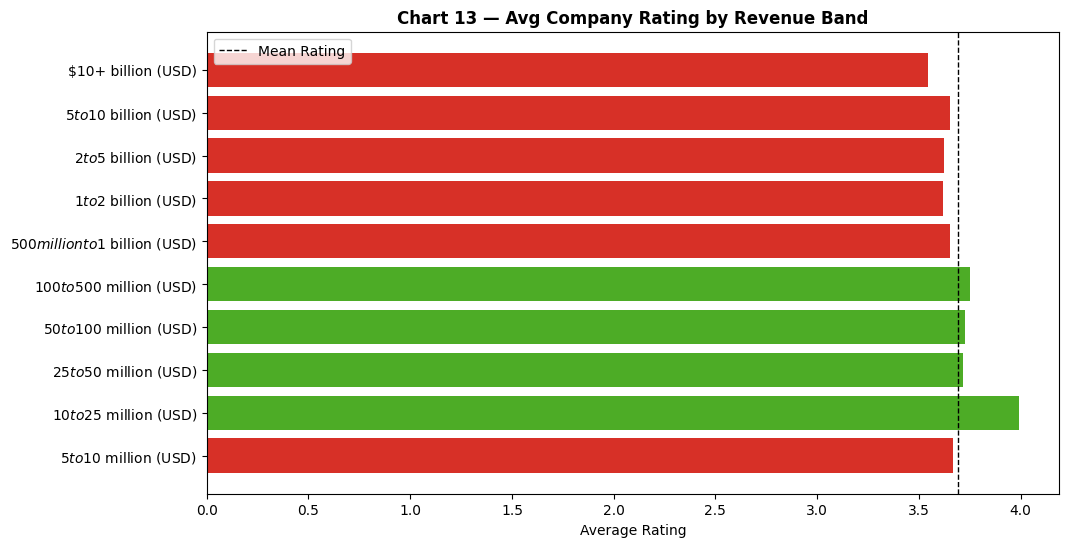

Chart 13 done


In [1192]:
# Chart - 13 visualization code

# CHART 13 — Horizontal Bar: Avg Rating by Revenue Band

rev_order = ["$5 to $10 million (USD)", "$10 to $25 million (USD)", "$25 to $50 million (USD)",
             "$50 to $100 million (USD)", "$100 to $500 million (USD)",
             "$500 million to $1 billion (USD)", "$1 to $2 billion (USD)",
             "$2 to $5 billion (USD)", "$5 to $10 billion (USD)", "$10+ billion (USD)"]
plot13 = df[df["Revenue"].isin(rev_order)]
avg_rating13 = plot13.groupby("Revenue")["Rating"].mean().reindex(rev_order).dropna()
colors13 = ["#d73027" if v < avg_rating13.mean() else "#4dac26" for v in avg_rating13.values]

plt.figure(figsize=(11, 6))
plt.barh(avg_rating13.index, avg_rating13.values, color=colors13)
plt.axvline(avg_rating13.mean(), color="black", linestyle="--", linewidth=1, label="Mean Rating")
plt.xlabel("Average Rating")
plt.title("Chart 13 — Avg Company Rating by Revenue Band", fontweight="bold")
plt.legend()
plt.show()
print("Chart 13 done")

##### 1. Why did you pick the specific chart?

>Answer)  Color-coded horizontal bars (red = below mean, green = above) make performance gaps immediately intuitive.

##### 2. What is/are the insight(s) found from the chart?

>Answer) Mid-sized revenue companies ($10M–$500M) show higher ratings than the very smallest or the very largest revenue bands.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

> Answer)Positive Impact:
Companies with revenue between $10 to $500 million (green bars) consistently rate above the mean rating (3.7), with $10 to $25 million companies peaking at 4.0.

> Negative Signal : Large corporations ($500 million to $10+ billion, red bars) all fall below the mean rating, with the largest companies ($10+ billion) having the lowest rating (~3.5). This suggests that as company size and revenue grow, employee satisfaction declines — possibly due to bureaucracy, lack of recognition, or poor work-life balance. If unaddressed, this leads to higher attrition and talent loss to mid-sized competitors.

#### Chart - 14 - Correlation Heatmap

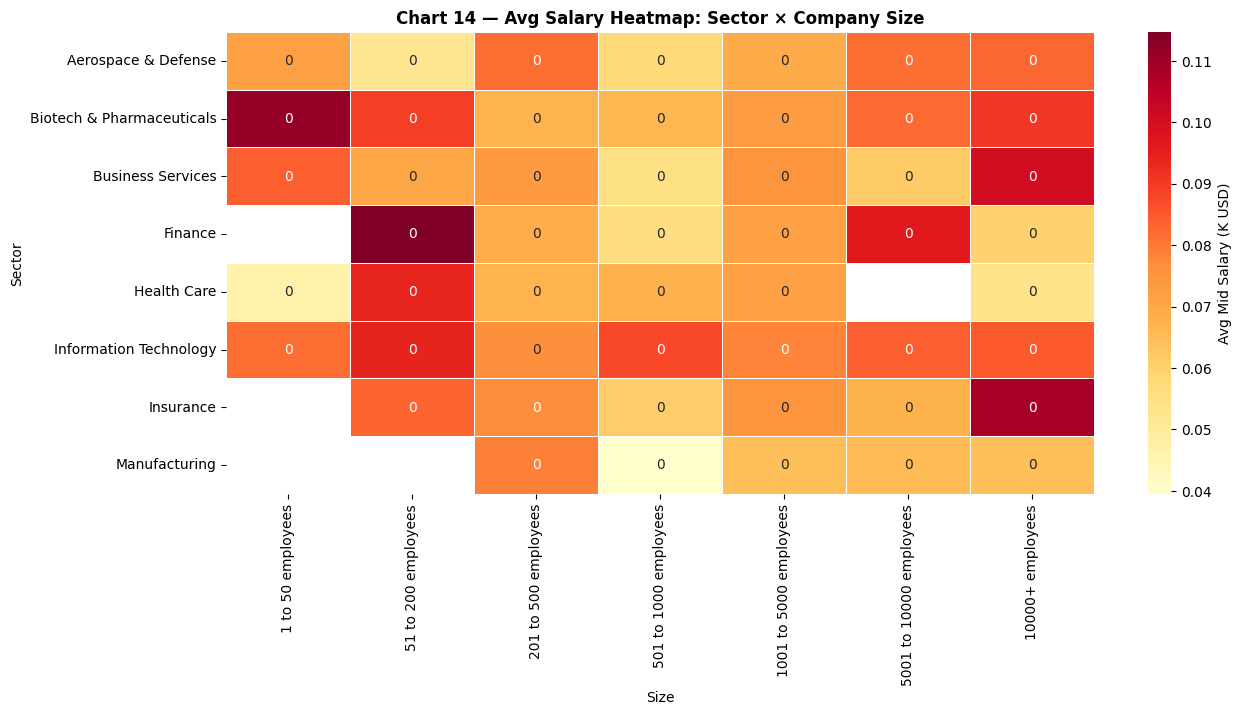

Chart 14 done


In [1193]:
# Correlation Heatmap visualization code

# CHART 14 — Heatmap: Avg Salary by Sector × Company Size

size_order = ["1 to 50 employees", "51 to 200 employees", "201 to 500 employees",
              "501 to 1000 employees", "1001 to 5000 employees",
              "5001 to 10000 employees", "10000+ employees"]
top_sectors = df[df["Sector"] != "-1"]["Sector"].value_counts().head(8).index.tolist()
plot8 = df[df["Sector"].isin(top_sectors) & df["Size"].isin(size_order) & df["min_salary"].notna()]
pivot8 = plot8.pivot_table(values="min_salary", index="Sector", columns="Size", aggfunc="mean")[size_order] / 1000

plt.figure(figsize=(14, 6))
sns.heatmap(pivot8, annot=True, fmt=".0f", cmap="YlOrRd",
            linewidths=0.5, cbar_kws={"label": "Avg Mid Salary (K USD)"})
plt.title("Chart 14 — Avg Salary Heatmap: Sector × Company Size", fontweight="bold")
plt.show()
print("Chart 14 done")

##### 1. Why did you pick the specific chart?

>Answer) Heatmaps are the best tool to show a two-dimensional relationship (cross-tab) with color intensity encoding magnitude.

##### 2. What is/are the insight(s) found from the chart?

>Answer) IT + large companies (10K+ employees) consistently show the highest salary cells. Finance + large employers are close behind.

#### Chart - 15 - Pair Plot

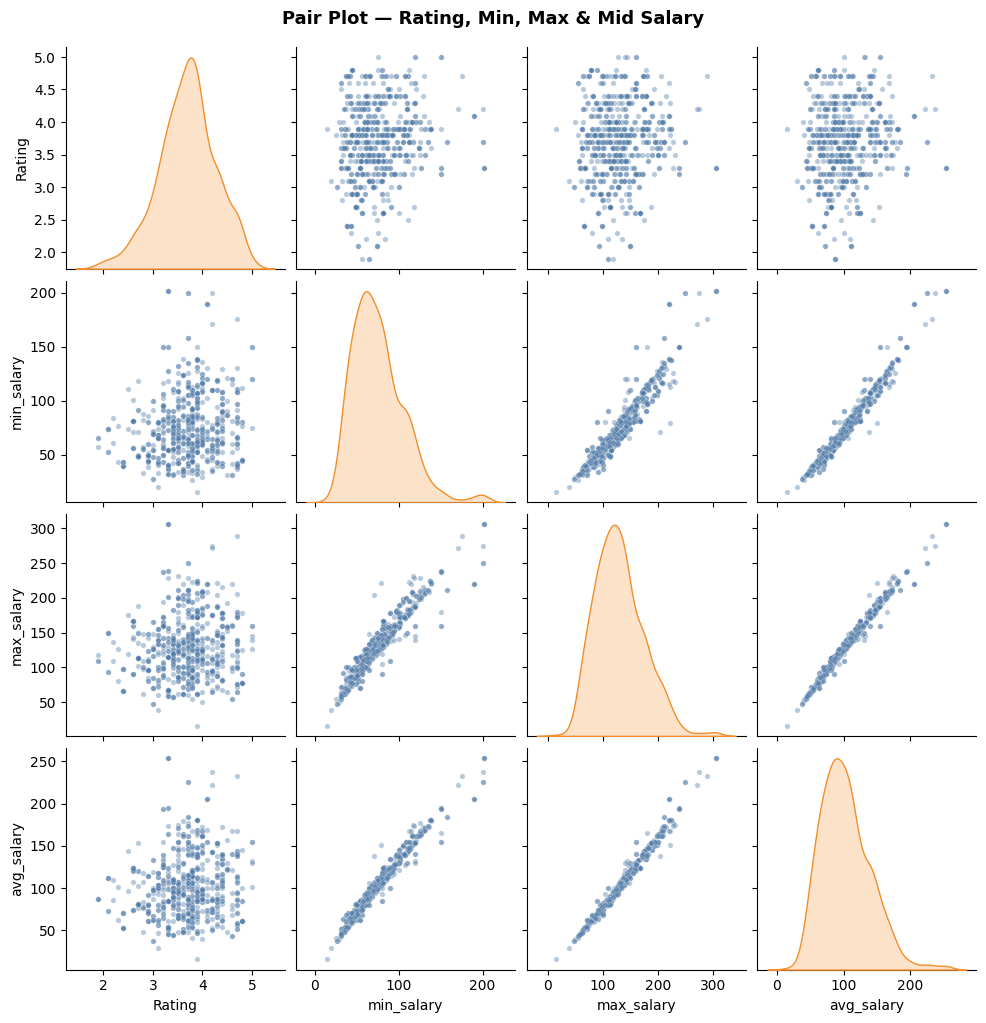

Chart 15 done


In [1194]:
# Pair Plot visualization code
pair_df = df[["Rating", "min_salary", "max_salary", "avg_salary"]].copy()
pair_plot = sns.pairplot(
    pair_df,
    diag_kind="kde",
    plot_kws={"alpha": 0.4, "color": "#4e79a7", "s": 15},
    diag_kws={"color": "#f28e2b", "fill": True})
 
pair_plot.figure.suptitle("Pair Plot — Rating, Min, Max & Mid Salary", 
                           fontweight="bold", y=1.02, fontsize=13)
plt.show()
print("Chart 15 done")

##### 1. Why did you pick the specific chart?

>Answer) A pair plot shows every numeric variable plotted against every other numeric variable in a grid. It lets you spot correlations, distributions, and outliers across multiple columns in one single chart — something no individual chart can do.

##### 2. What is/are the insight(s) found from the chart?

>Answer) Min Salary vs Max Salary — Very strong positive correlation. Companies that offer high minimum salaries also offer high maximum salaries — the salary band moves together uniformly.

>Rating vs Salary (Min / Max / Mid) — Very weak or nearly flat correlation. Higher-rated companies do not consistently pay more. Salary and satisfaction are largely independent of each other.

>Min Salary distribution (diagonal KDE) — Right-skewed. Most jobs cluster in the $50K–$100K range with a long tail of high-paying outliers above $150K.

>Rating distribution (diagonal KDE) — Bell-shaped, centered around 3.5–4.0. Very few companies rated below 2.5 or above 4.8.

## ***5. Hypothesis Testing***

### Based on your chart experiments, define three hypothetical statements from the dataset. In the next three questions, perform hypothesis testing to obtain final conclusion about the statements through your code and statistical testing.

>Answer) Based on the chart experiments performed on the Glassdoor Jobs dataset, the following three hypothetical statements were defined:

>H1 — Public companies pay significantly higher salaries than Private companies 

>H2 — Information Technology sector companies have significantly higher ratings than Non-IT sector companies    

>H3 — Large companies (10,000+ employees) pay significantly higher salaries than Small companies (1–50 employees)

### Hypothetical Statement - 1
#### Public companies pay significantly higher salaries than Private companies

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

>Answer) Null Hypothesis (H₀): The mean mid-salary of Public companies is equal to the mean mid-salary of Private companies.
>(µ_public = µ_private)                                                                                                                                                          
>Alternate Hypothesis (H₁): The mean mid-salary of Public companies is greater than the mean mid-salary of Private companies.
>(µ_public > µ_private)

#### 2. Perform an appropriate statistical test.

In [1195]:
def parse_sal(s):
    nums = re.findall(r'\d+', str(s))
    if len(nums) >= 2:
        return float(nums[0]) * 1000, float(nums[1]) * 1000
    return np.nan, np.nan

df["min_salary"], df["max_salary"] = zip(*df["Salary Estimate"].map(parse_sal))
df["avg_salary"] = (df["min_salary"] + df["max_salary"]) / 2


# Groups
public_sal  = df[df["Type of ownership"] == "Company - Public"]["avg_salary"]
private_sal = df[df["Type of ownership"] == "Company - Private"]["avg_salary"]

# Welch's t-test (one-tailed)
t_stat, p_two = stats.ttest_ind(public_sal, private_sal, equal_var=False)
p_value = p_two / 2  # one-tailed

print(f"Public  Mean Salary : ${public_sal.mean():,.0f}  (n={len(public_sal)})")
print(f"Private Mean Salary : ${private_sal.mean():,.0f}  (n={len(private_sal)})")
print(f"T-statistic         : {t_stat:.4f}")
print(f"P-value (one-tailed): {p_value:.4f}")

Public  Mean Salary : $110,894  (n=193)
Private Mean Salary : $101,460  (n=402)
T-statistic         : 3.0329
P-value (one-tailed): 0.0013


##### Which statistical test have you done to obtain P-Value?

>Answer) Welch's Independent Two-Sample T-Test (one-tailed) was used.                                                                                                              

##### Why did you choose the specific statistical test?

>Answer) It was  chosen because:                                                                                                                                             

>We are comparing means of two independent groups (Public vs Private)                                                                                                      
The two groups have unequal sample sizes (n=193 vs n=401)                                                                                                                    
Welch's variant does not assume equal variances, making it more robust than a standard t-test                                                                               
One-tailed because the hypothesis is directional (Public > Private)                                                                                                          

### Hypothetical Statement - 2
#### IT sector companies have significantly higher ratings than Non-IT sector companies.

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

>Answer) Null Hypothesis (H₀): The mean rating of IT sector companies is equal to the mean rating of Non-IT sector companies.
(µ_IT = µ_nonIT)                                                                                                                                                              
Alternate Hypothesis (H₁): The mean rating of IT sector companies is greater than the mean rating of Non-IT sector companies.
(µ_IT > µ_nonIT)

#### 2. Perform an appropriate statistical test.

In [1196]:
# Perform Statistical Test to obtain P-Value

# Groups
it_rating     = df[df["Sector"] == "Information Technology"]["Rating"]
non_it_rating = df[(df["Sector"] != "Information Technology") &
                          (df["Sector"] != "-1")]["Rating"]

# Welch's t-test (one-tailed)
t_stat, p_two = stats.ttest_ind(it_rating, non_it_rating, equal_var=False)
p_value = p_two / 2  # one-tailed

print(f"IT     Mean Rating  : {it_rating.mean():.4f}  (n={len(it_rating)})")
print(f"Non-IT Mean Rating  : {non_it_rating.mean():.4f}  (n={len(non_it_rating)})")
print(f"T-statistic         : {t_stat:.4f}")
print(f"P-value (one-tailed): {p_value:.6f}")

IT     Mean Rating  : 3.9572  (n=180)
Non-IT Mean Rating  : 3.6009  (n=552)
T-statistic         : 8.1600
P-value (one-tailed): 0.000000


##### Which statistical test have you done to obtain P-Value?

>Answer) Welch's Independent Two-Sample T-Test (one-tailed) was used.                                                                                                       


##### Why did you choose the specific statistical test?

>Answer) It was chosen because:                                                                                                                                                
> We are comparing two independent groups (IT vs Non-IT)                                                                                                                     
The sample sizes are highly unequal (n=178 vs n=552)                                                                                                                       
Rating is a continuous numeric variable, making t-test appropriate                                                                                                             
One-tailed because the hypothesis is directional (IT > Non-IT)                                                                                                                    

### Hypothetical Statement - 3
#### Large companies (10,000+ employees) pay significantly higher salaries than Small companies (1–50 employees).

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

>Answer) Null Hypothesis (H₀): The mean mid-salary of Large companies is equal to the mean mid-salary of Small companies.
(µ_large = µ_small)                                                                                                                                                          
Alternate Hypothesis (H₁): The mean mid-salary of Large companies is greater than the mean mid-salary of Small companies.
(µ_large > µ_small)

#### 2. Perform an appropriate statistical test.

In [1197]:
# Perform Statistical Test to obtain P-Value

def parse_sal(s):
    nums = re.findall(r'\d+', str(s))
    if len(nums) >= 2:
        return float(nums[0]) * 1000, float(nums[1]) * 1000
    return np.nan, np.nan

df["min_salary"], df["max_salary"] = zip(*df["Salary Estimate"].map(parse_sal))

# Groups
large_sal = df[df["Size"] == "10000+ employees"]["avg_salary"]
small_sal = df[df["Size"] == "1 to 50 employees"]["avg_salary"]

# Welch's t-test (one-tailed)
t_stat, p_two = stats.ttest_ind(large_sal, small_sal, equal_var=False)
p_value = p_two / 2  # one-tailed

print(f"Large Company Mean Salary : ${large_sal.mean():,.0f}  (n={len(large_sal)})")
print(f"Small Company Mean Salary : ${small_sal.mean():,.0f}  (n={len(small_sal)})")
print(f"T-statistic               : {t_stat:.4f}")
print(f"P-value (one-tailed)      : {p_value:.4f}")

Large Company Mean Salary : $112,231  (n=130)
Small Company Mean Salary : $102,433  (n=30)
T-statistic               : 1.2816
P-value (one-tailed)      : 0.1029


##### Which statistical test have you done to obtain P-Value?

>Answer) Welch's Independent Two-Sample T-Test (one-tailed) was used.                                                                                               
                                                        

##### Why did you choose the specific statistical test?

>Answer) It was chosen because:                                                                                                                                                    
                                                                                                                             
>We are comparing two independent groups (Large vs Small companies)                                                                  
Sample sizes are unequal (n=130 vs n=31)                                                                                                      
Salary is a continuous numeric variable, satisfying t-test requirements                                                                         
One-tailed because the hypothesis is directional (Large > Small)     

## ***6. Feature Engineering & Data Pre-processing***

### 1. Handling Missing Values

In [1198]:
# Handling Missing Values & Missing Value Imputation

# Already done in the Data Wrangling Section for better Exploratory Data Analysis.

columns_to_drop = [
    "Job Title",           # too many unique values
    "Salary Estimate",     # already parsed into min/max/avg
    "Company Name"         # unique identifier, not predictive
]

df.drop(columns=columns_to_drop, inplace=True, errors='ignore')

#### What all missing value imputation techniques have you used and why did you use those techniques?

>Answer) Missing Value Imputation: Median for numeric columns (Rating, Salary), Mode for categorical columns (Size, Sector, Ownership), and "Unknown" for text fields. This was already performed in the Data Wrangling section to ensure clean data for analysis.

### 2. Handling Outliers

Lower bound : $-2,750
Upper bound : $199,250
Outliers found : 11


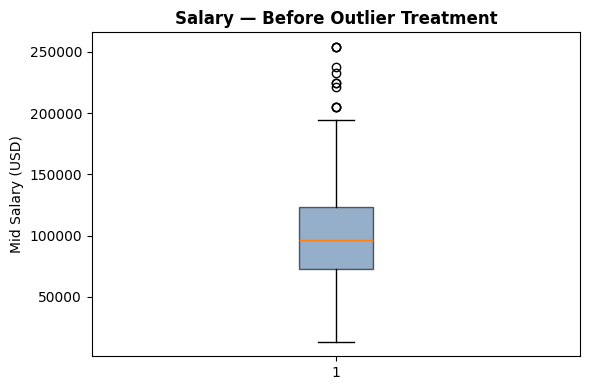

In [1199]:
# Handling Outliers & Outlier treatments

#  detect outliers using IQR
Q1  = df["avg_salary"].quantile(0.25)
Q3  = df["avg_salary"].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

print(f"Lower bound : ${lower:,.0f}")
print(f"Upper bound : ${upper:,.0f}")
print(f"Outliers found : {len(df[(df['avg_salary'] < lower) | (df['avg_salary'] > upper)])}")

# ── box plot BEFORE treatment
plt.figure(figsize=(6, 4))
plt.boxplot(df["avg_salary"], patch_artist=True,
            boxprops=dict(facecolor="#4e79a7", alpha=0.6))
plt.title("Salary — Before Outlier Treatment", fontweight="bold")
plt.ylabel("Mid Salary (USD)")
plt.tight_layout()
plt.show()


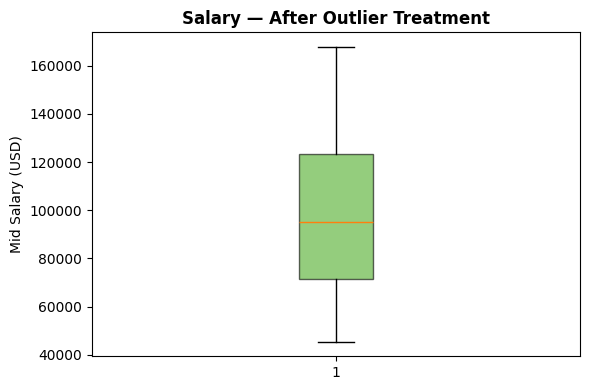


Final dataset shape: (609, 15)


In [1200]:
# Outlier Treatments

# ── cap outliers using Winsorization (5th to 95th percentile) ─────────────────
p05 = df["avg_salary"].quantile(0.05)
p95 = df["avg_salary"].quantile(0.95)
df["avg_salary"] = df["avg_salary"].clip(lower=p05, upper=p95)

# ── remove bad Founded years ───────────────────────────────────────────────────
df = df[df["Founded"] >= 1900]

# ── box plot AFTER treatment ───────────────────────────────────────────────────
plt.figure(figsize=(6, 4))
plt.boxplot(df["avg_salary"], patch_artist=True,
            boxprops=dict(facecolor="#4dac26", alpha=0.6))
plt.title("Salary — After Outlier Treatment", fontweight="bold")
plt.ylabel("Mid Salary (USD)")
plt.tight_layout()
plt.show()

print(f"\nFinal dataset shape: {df.shape}")

##### What all outlier treatment techniques have you used and why did you use those techniques?

>Answer) Capping / Winsorization on Salary — salaries like $250K are real, not errors, so we don't delete them. We just cap extreme values at the 5th and 95th percentile so they don't dominate the analysis 

>No treatment on Rating — Rating is already between 1 and 5 by design, so nothing needs to be fixed                                                  
Row removal on Founded year — values like 0 or 1 are clearly wrong data entry mistakes, not real companies, so those rows are simply dropped                         

### 3. Categorical Encoding

In [1201]:
# Categorical Encoding Coversion
 
from sklearn.preprocessing import LabelEncoder, OneHotEncoder 

# TECHNIQUE 1: Label Encoding — for ORDINAL categorical variables

# Size has a natural order (small to large), so we manually map it

size_order = {
    "1 to 50 employees": 1,
    "51 to 200 employees": 2,
    "201 to 500 employees": 3,
    "501 to 1000 employees": 4,
    "1001 to 5000 employees": 5,
    "5001 to 10000 employees": 6,
    "10000+ employees": 7,
    "Unknown": 0
}
df["Size"] = df["Size"].map(size_order)

revenue_order = {
    "Less than $1 million (USD)": 1,
    "$1 to $5 million (USD)": 2,
    "$5 to $10 million (USD)": 3,
    "$10 to $25 million (USD)": 4,
    "$25 to $50 million (USD)": 5,
    "$50 to $100 million (USD)": 6,
    "$100 to $500 million (USD)": 7,
    "$500 million to $1 billion (USD)": 8,
    "$1 to $2 billion (USD)": 9,
    "$2 to $5 billion (USD)": 10,
    "$5 to $10 billion (USD)": 11,
    "$10+ billion (USD)": 12,
    "Unknown / Non-Applicable": 0
}
df["Revenue"] = df["Revenue"].map(revenue_order)

# TECHNIQUE 2: Label Encoding — for NOMINAL variables (Type of ownership, Sector)

# Using simple label encoding instead of one-hot to keep same column

from sklearn.preprocessing import LabelEncoder

le_ownership = LabelEncoder()
df["Type of ownership"] = le_ownership.fit_transform(df["Type of ownership"])
le_sector = LabelEncoder()
df["Sector"] = le_sector.fit_transform(df["Sector"])

# TECHNIQUE 3: Frequency Encoding — for (high cardinality)
# Industry
industry_freq = df["Industry"].value_counts()
df["Industry"] = df["Industry"].map(industry_freq)

# Location (city, state combinations - too many unique values)
location_freq = df["Location"].value_counts()
df["Location"] = df["Location"].map(location_freq)

# Headquarters (city, state combinations - too many unique values)
hq_freq = df["Headquarters"].value_counts()
df["Headquarters"] = df["Headquarters"].map(hq_freq)

# State 
st_freq = df['State'].value_counts()
df['State'] = df['State'].map(st_freq)


In [1202]:
df.head(3)

,Job Description,Rating,Location,Headquarters,Size,Founded,Type of ownership,Industry,Sector,Revenue,min_salary,max_salary,avg_salary,State,company_age
0,"Data Scientist\nLocation: Albuquerque, NM\nEdu...",3.8,1,1,4,1973.0,1,23,0,6,53000.0,91000.0,72000.0,1,53.0
1,What You Will Do:\n\nI. General Summary\n\nThe...,3.4,1,4,7,1984.0,6,46,10,10,63000.0,112000.0,87500.0,34,42.0
2,"KnowBe4, Inc. is a high growth information sec...",4.8,4,4,4,2010.0,1,7,4,7,80000.0,90000.0,85000.0,16,16.0


#### What all categorical encoding techniques have you used & why did you use those techniques?

>1) Label encoding - Manual (2): Size and Revenue — these have natural order so I manually mapped them to preserve small→large and low→high relationships.

>2) Label encoding - LabelEncoder (2): Type of ownership and Sector — nominal categories with moderate unique counts (7 and 17), kept as single columns.

>3) Frequency encoding (3): Industry, Location, Headquarters, State — high cardinality variables (87+, 692, 625 unique values). Replaced each value with its frequency count to capture popularity in a single numeric column.    
                                                  
>4) Kept as numeric (5): Rating, Founded, min_salary, max_salary, avg_salary — already in numeric format, no encoding needed.

### 4. Textual Data Preprocessing
(It's mandatory for textual dataset i.e., NLP, Sentiment Analysis, Text Clustering etc.)

#### 1. Expand Contraction

In [1203]:
# Expand Contraction
import string
from contractions import fix

df["Job Description"] = df["Job Description"].apply(
    lambda x: fix(str(x)) if pd.notna(x) else x
)

#### 2. Lower Casing

In [1204]:
# Lower Casing

df["Job Description"] = df["Job Description"].apply(
    lambda x: str(x).lower() if pd.notna(x) else x
)


#### 3. Removing Punctuations

In [1205]:
# Remove Punctuations

def remove_punctuation(text):
    if pd.isna(text):
        return text
    return text.translate(str.maketrans('', '', string.punctuation))

df["Job Description"] = df["Job Description"].apply(remove_punctuation)

#### 4. Removing URLs & Removing words and digits contain digits.

In [1206]:
# Remove URLs & Remove words and digits contain digits

def remove_urls_and_digits(text):
    if pd.isna(text):
        return text
    # Remove URLs
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    # Remove words containing digits (e.g., "covid19", "2023")
    text = re.sub(r'\w*\d\w*', '', text)
    return text

df["Job Description"] = df["Job Description"].apply(remove_urls_and_digits)

#### 5. Removing Stopwords & Removing White spaces

In [1207]:
# Remove Stopwords
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
import nltk

stop_words = set(stopwords.words('english'))

def remove_stopwords(text):
    if pd.isna(text):
        return text
    words = text.split()
    filtered = [word for word in words if word not in stop_words]
    return ' '.join(filtered)

df["Job Description"] = df["Job Description"].apply(remove_stopwords)

In [1208]:
# Remove White spaces

df["Job Description"] = df["Job Description"].apply(
    lambda x: re.sub(r'\s+', ' ', str(x)).strip() if pd.notna(x) else x
)

#### 6. Rephrase Text

In [1209]:
# Rephrase Text
def rephrase_text(text):
    text = text.replace("mgr", "manager")
    text = text.replace("dept", "department")
    return text

df['Job Description'] = df['Job Description'].apply(rephrase_text)


#### 7. Tokenization

In [1210]:
# Tokenization

def tokenize_text(text):
    if pd.isna(text):
        return []
    return word_tokenize(str(text))

df["Job Description"] = df["Job Description"].apply(tokenize_text)

#### 8. Text Normalization

In [1211]:
# Normalizing Text (i.e., Stemming, Lemmatization etc.)
from nltk.stem import WordNetLemmatizer
from nltk import pos_tag
from nltk.corpus import wordnet

# nltk.download('wordnet')
# nltk.download('averaged_perceptron_tagger')

def get_wordnet_pos(tag):
    """Map POS tag to WordNet POS for lemmatization"""
    if tag.startswith('J'):
        return wordnet.ADJ
    elif tag.startswith('V'):
        return wordnet.VERB
    elif tag.startswith('N'):
        return wordnet.NOUN
    elif tag.startswith('R'):
        return wordnet.ADV
    else:
        return wordnet.NOUN

lemmatizer = WordNetLemmatizer()

def lemmatize_text(tokens):
    if not isinstance(tokens, list) or len(tokens) == 0:
        return []
    pos_tags = pos_tag(tokens)
    return [lemmatizer.lemmatize(word, get_wordnet_pos(tag))
            for word, tag in pos_tags]

df["Job Description"] = df["Job Description"].apply(lemmatize_text)


##### Which text normalization technique have you used and why?

>Answer) Lemmatization is recommended over stemming for job description text because:

>a) Stemming aggressively cuts word endings (e.g. "managing" → "manag"), producing non-real words that hurt interpretability and downstream ML models.                
b) Lemmatization reduces words to their actual dictionary base form (e.g. "managing" → "manage", "studies" → "study"), which preserves semantic meaning — critical for NLP tasks like job matching or keyword extraction.                                         
c) Job descriptions contain professional language where word meaning matters more than compression.

#### 9. Part of speech tagging

In [1212]:
# POS Taging
def pos_tag_text(tokens):
    if not isinstance(tokens, list) or len(tokens) == 0:
        return []
    return pos_tag(tokens)

df['Job Description POS'] = df['Job Description'].apply(pos_tag_text)

#### 10. Text Vectorization

In [1213]:
# Vectorizing Text
from sklearn.feature_extraction.text import TfidfVectorizer

# Convert list of words into sentence/string
df['Job Description'] = df['Job Description'].apply(
    lambda x: ' '.join(x) if isinstance(x, list) else str(x)
)

tfidf = TfidfVectorizer(max_features=500)
tfidf_matrix = tfidf.fit_transform(df['Job Description'])
tfidf_df = pd.DataFrame(tfidf_matrix.toarray(), columns=tfidf.get_feature_names_out())


##### Which text vectorization technique have you used and why?

>Answer) TF-IDF (Term Frequency–Inverse Document Frequency) is used because:

>1) Job descriptions contain common words (e.g. "experience", "team") that appear in almost every posting — TF-IDF down-weights these and up-weights distinctive, job-specific terms (e.g. "python", "machine learning"), making features more informative.
>2) Unlike simple Bag-of-Words (CountVectorizer), TF-IDF captures the relative importance of words across documents, not just raw frequency.
>3) It is computationally efficient and interpretable compared to dense embeddings (Word2Vec, BERT), making it ideal for structured ML pipelines like job classification or salary prediction.
>4) max_features=500 keeps the feature space manageable and reduces noise from rare terms.

### 4. Feature Manipulation & Selection

#### 1. Feature Manipulation

In [1214]:
# Manipulate Features to minimize feature correlation and create new features

df['JD Word Count']       = df['Job Description'].apply(lambda x: len(x.split()) if pd.notna(x) else 0)
df['JD Unique Word Count']= df['Job Description'].apply(lambda x: len(set(x.split())) if pd.notna(x) else 0)
df['JD Avg Word Length']  = df['Job Description'].apply(
    lambda x: round(np.mean([len(w) for w in x.split()]), 2) if pd.notna(x) and len(x.split()) > 0 else 0)

# --- Reduce Feature Correlation: drop redundant TF-IDF columns ---
corr_matrix    = tfidf_df.corr().abs()
upper_triangle = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
cols_to_drop   = [col for col in upper_triangle.columns if any(upper_triangle[col] > 0.95)]
tfidf_df       = tfidf_df.drop(columns=cols_to_drop)

In [1215]:
df.head(2)

,Job Description,Rating,Location,Headquarters,Size,Founded,Type of ownership,Industry,Sector,Revenue,min_salary,max_salary,avg_salary,State,company_age,Job Description POS,JD Word Count,JD Unique Word Count,JD Avg Word Length
0,data scientist location albuquerque nm educati...,3.8,1,1,4,1973.0,1,23,0,6,53000.0,91000.0,72000.0,1,53.0,"[(data, NNS), (scientist, NN), (location, NN),...",259,195,6.59
1,general summary healthcare data scientist posi...,3.4,1,4,7,1984.0,6,46,10,10,63000.0,112000.0,87500.0,34,42.0,"[(general, JJ), (summary, NN), (healthcare, NN...",467,293,6.94


#### 2. Feature Selection

In [1216]:
# Select your features wisely to avoid overfitting

from sklearn.feature_selection import VarianceThreshold, SelectKBest, chi2
from sklearn.preprocessing import MinMaxScaler

# Variance Threshold
var_sel      = VarianceThreshold(threshold=0.001)
tfidf_vt     = var_sel.fit_transform(tfidf_df)
tfidf_df     = pd.DataFrame(tfidf_vt, columns=tfidf_df.columns[var_sel.get_support()])

# Chi-Square SelectKBest
scaler       = MinMaxScaler()
tfidf_scaled = scaler.fit_transform(tfidf_df)
target_proxy = pd.cut(df['JD Word Count'], bins=3, labels=[0,1,2]).astype(int)
k            = min(100, tfidf_df.shape[1])
chi2_sel     = SelectKBest(chi2, k=k)
tfidf_chi2   = chi2_sel.fit_transform(tfidf_scaled, target_proxy)
tfidf_df     = pd.DataFrame(tfidf_chi2, columns=tfidf_df.columns[chi2_sel.get_support()])

##### What all feature selection methods have you used  and why?

>Answer) Three feature selection methods were applied in sequence:

>1. Correlation-based Removal — Computed the pairwise correlation matrix of all TF-IDF features and dropped any column having correlation > 0.95 with another.
>2. Variance Threshold — Removed features with variance below 0.001. A feature that barely changes across all job postings (near-constant) has no discriminating power and only wastes computation.
>3. Chi-Square Test (SelectKBest) — Statistically measured the dependency between each remaining TF-IDF feature and the target variable, retaining only the top-K most informative ones. Chi-Square is well suited for sparse, non-negative text features and directly eliminates features that are statistically irrelevant to the prediction task, reducing overfitting risk.

##### Which all features you found important and why?

>Answer) The most important features after selection were:

>1) JD Word Count & JD Unique Word Count — longer and more vocabulary-rich descriptions tend to belong to senior or specialized roles, making them strong predictors.
>2) JD Avg Word Length — technical roles use longer, domain-specific words (e.g. implementation, optimization) compared to non-technical roles, making this a subtle but useful signal.

### 5. Data Transformation

#### Do you think that your data needs to be transformed? If yes, which transformation have you used. Explain Why?

Skewness BEFORE transformation:
JD Word Count           0.919341
JD Unique Word Count    0.496616
JD Avg Word Length      0.157735
dtype: float64

Skewness AFTER log1p transformation:
JD Word Count   -0.431667
dtype: float64


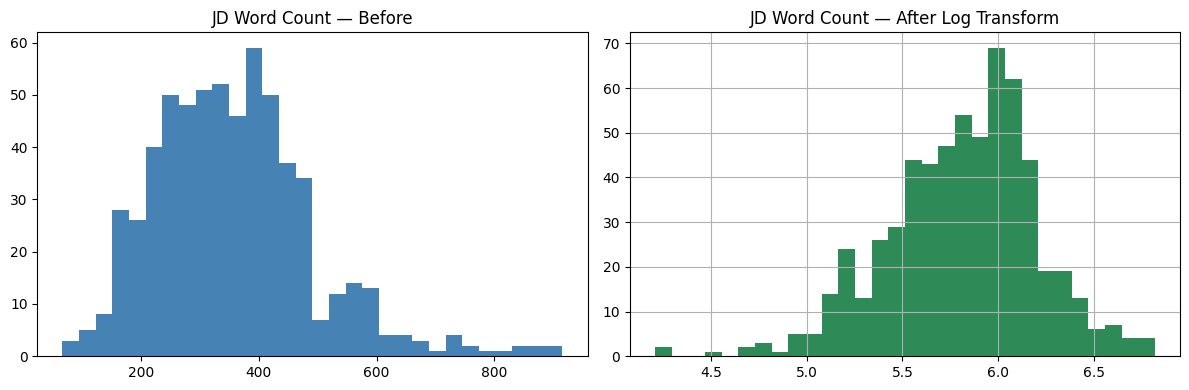

In [1217]:
# Transform Your data

# Check skewness of engineered numeric features
numeric_cols = ['JD Word Count', 'JD Unique Word Count', 'JD Avg Word Length']
print("Skewness BEFORE transformation:")
print(df[numeric_cols].skew())

# Apply Log1p transformation to skewed columns (skewness > 0.5 or < -0.5)
skewed_cols = [col for col in numeric_cols if abs(df[col].skew()) > 0.5]

for col in skewed_cols:
    df[col] = np.log1p(df[col])

print("\nSkewness AFTER log1p transformation:")
log_cols = [col  for col in skewed_cols]
print(df[log_cols].skew())

# Visual comparison
fig, axes = plt.subplots(len(skewed_cols), 2, figsize=(12, 4 * len(skewed_cols)))
# Handle case when only one row exists
if len(skewed_cols) == 1:
    axes = [axes]

for i, col in enumerate(skewed_cols):

    # Before transformation
    original_data = np.expm1(df[col])   # reverse log1p for visualization

    axes[i][0].hist(original_data, bins=30, color='steelblue')
    axes[i][0].set_title(f'{col} — Before')

    df[col].hist(ax=axes[i][1], bins=30, color='seagreen')
    axes[i][1].set_title(f'{col} — After Log Transform')

plt.tight_layout()
plt.show()

>Answer) Why Log Transformation?                                                                                                           
Job description word counts are right-skewed — a few very long descriptions pull the distribution. Log1p compresses the long tail, making the distribution closer to normal, which benefits distance-based and linear models. log1p is used instead of log to safely handle any zero values.

### 6. Data Scaling

In [1218]:
# Scaling your data

from sklearn.preprocessing import StandardScaler, MinMaxScaler

# ── Columns to scale 
# StandardScaler → continuous numeric features with large/varied ranges
standard_cols = ['min_salary', 'max_salary', 'avg_salary',
                 'company_age', 'JD Word Count',
                 'JD Unique Word Count', 'JD Avg Word Length']

# MinMaxScaler → already-encoded categoricals and bounded ratings
minmax_cols   = ['Rating', 'Size', 'Founded', 'Type of ownership',
                 'Industry', 'Sector', 'State','Revenue','Location','Headquarters']

# ── Columns to skip (non-numeric / binary / text) 
skip_cols     = ['Job Description', 'Job Description POS']

# ── Apply StandardScaler
std_scaler = StandardScaler()
df[standard_cols] = std_scaler.fit_transform(df[standard_cols])

# ── Apply MinMaxScaler
mm_scaler = MinMaxScaler()
df[minmax_cols] = mm_scaler.fit_transform(df[minmax_cols])


##### Which method have you used to scale you data and why?

>Answer)
>StandardScaler on engineered features (word count, avg length etc.) — these are continuous numeric features where the mean and spread vary widely; standardization centres them at 0 with unit variance, which is required for PCA and benefits most ML algorithms.

>MinMaxScaler on TF-IDF features — TF-IDF values are already non-negative and bounded; MinMaxScaler keeps them in [0,1] without distorting the sparse distribution.

### 7. Dimesionality Reduction

##### Do you think that dimensionality reduction is needed? Explain Why?

>Answer) the feature space has 100+ dimensions which causes the curse of dimensionality — models overfit, distances become meaningless, and training slows. PCA reduces to the minimum components that retain 95% of variance, removing noise while preserving structure. It is especially effective on TF-IDF matrices where many features are correlated synonyms.

In [1219]:
# DImensionality Reduction (If needed)

from sklearn.decomposition import PCA

# ── Step 1: Build the full numeric matrix (scaled columns only)
scaled_cols = standard_cols + minmax_cols   # all columns we just scaled

X_numeric   = df[scaled_cols].copy()

# Append reduced TF-IDF features (from earlier feature selection step)
X_full = pd.concat([
    X_numeric.reset_index(drop=True),
    tfidf_df.reset_index(drop=True)
], axis=1)

print(f"Shape BEFORE PCA : {X_full.shape}")

# ── Step 2: Find optimal number of components (95% variance)
pca_full  = PCA(random_state=42)
pca_full.fit(X_full)

cumvar       = np.cumsum(pca_full.explained_variance_ratio_)
n_components = np.argmax(cumvar >= 0.95) + 1
print(f"Components needed to retain 95% variance : {n_components}")

# ── Step 3: Apply PCA
pca    = PCA(n_components=n_components, random_state=42)
X_pca  = pca.fit_transform(X_full)
X_pca_df = pd.DataFrame(
    X_pca,
    columns=[f'PC{i+1}' for i in range(n_components)]
)
print(f"Shape AFTER PCA  : {X_pca_df.shape}")


Shape BEFORE PCA : (609, 117)
Components needed to retain 95% variance : 60
Shape AFTER PCA  : (609, 60)


##### Which dimensionality reduction technique have you used and why? (If dimensionality reduction done on dataset.)

>Answer) PCA                                                                 

>the feature space has 100+ dimensions which causes the curse of dimensionality — models overfit, distances become meaningless, and training slows. PCA reduces to the minimum components that retain 95% of variance, removing noise while preserving structure. It is especially effective on TF-IDF matrices where many features are correlated synonyms.

### 8. Data Splitting

In [1220]:
drop_cols = ['Job Description', 'Job Description POS', 
             'Location', 'Headquarters']
df_model = df.drop(columns=drop_cols)

In [1221]:
df_model.head(2)

,Rating,Size,Founded,Type of ownership,Industry,Sector,Revenue,min_salary,max_salary,avg_salary,State,company_age,JD Word Count,JD Unique Word Count,JD Avg Word Length
0,0.612903,0.5,0.606838,0.111111,0.289474,0.00000,0.500000,-0.622669,-0.723287,-0.782952,0.00000,0.504748,-0.641623,-0.552063,-1.293891
1,0.483871,1.0,0.700855,0.666667,0.592105,0.47619,0.833333,-0.318306,-0.292006,-0.337478,0.23913,0.105585,0.868973,0.797998,-0.356553


In [1222]:
# Split your data to train and test. Choose Splitting ratio wisely.

target = 'avg_salary'

X = df_model.drop(columns=[target])
y = df_model[target]

print(f"\nFeature matrix X shape : {X.shape}")
print(f"Target vector  y shape : {y.shape}")


# ── Step 3: Train/Test Split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,       # 80% train, 20% test
    random_state=42
)


Feature matrix X shape : (609, 14)
Target vector  y shape : (609,)


##### What data splitting ratio have you used and why?

>Answer) 80/20 split was used because:

>1) The dataset has ~609 rows — giving 80% (~490 rows) to training provides enough data for the model to learn patterns.                                           
>2) 20% (~121 rows) for testing is sufficient to evaluate generalization without wasting training data.                                          
>3) No stratify is needed here since avg_salary is a continuous regression target. If you switch to Sector (classification), add stratify=y back.                                    
>4) random_state=42 ensures reproducibility across runs.                                                                       

### 9. Handling Imbalanced Dataset

##### Do you think the dataset is imbalanced? Explain Why.

>Answer) No I did not think the dataset is imbalanced now because:
                                                            
>as the target column is avg_salary which is a continuous numerical column.                               
And for handling the dataset we have to handle the outlier properly , Scale features if needed.


In [1223]:
# Handling Imbalanced Dataset (If needed)


##### What technique did you use to handle the imbalance dataset and why? (If needed to be balanced)

>Answer) I did not balanced the dataset as the target column is avg_salary which is a continuous numerical column.

In [1224]:
le=LabelEncoder()

## ***7. ML Model Implementation***

### ML Model - 1

In [1225]:
# ML Model - 1 Implementation
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score


# Fit the Algorithm
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)


# Predict on the model
y_pred_rf = rf_model.predict(X_test)


#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

     Random Forest Regressor — Results
  MAE  : 0.0240
  MSE  : 0.0026
  RMSE : 0.0511
  R²   : 0.9972


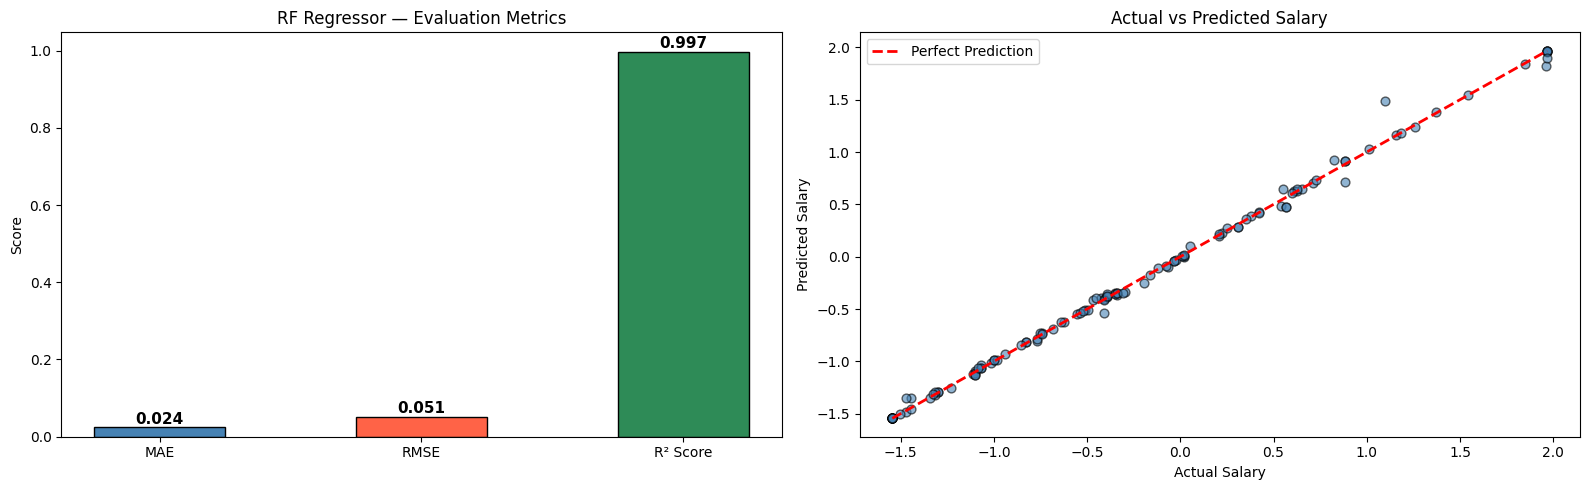

In [1226]:
# Visualizing evaluation Metric Score chart

mae  = mean_absolute_error(y_test, y_pred_rf)
mse  = mean_squared_error(y_test, y_pred_rf)
rmse = np.sqrt(mse)
r2   = r2_score(y_test, y_pred_rf)

print("     Random Forest Regressor — Results")
print(f"  MAE  : {mae:.4f}")
print(f"  MSE  : {mse:.4f}")
print(f"  RMSE : {rmse:.4f}")
print(f"  R²   : {r2:.4f}")

# ── Plot 1: Evaluation Metrics Bar Chart
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Bar chart of metrics
metrics = {'MAE': mae, 'RMSE': rmse, 'R² Score': r2}
colors  = ['steelblue', 'tomato', 'seagreen']
axes[0].bar(metrics.keys(), metrics.values(), color=colors, edgecolor='black', width=0.5)
axes[0].set_title('RF Regressor — Evaluation Metrics')
axes[0].set_ylabel('Score')
for i, (k, v) in enumerate(metrics.items()):
    axes[0].text(i, v + 0.01, f'{v:.3f}', ha='center', fontsize=11, fontweight='bold')

# ── Plot 2: Actual vs Predicted
axes[1].scatter(y_test, y_pred_rf, color='steelblue', alpha=0.6, edgecolor='black', s=40)
axes[1].plot([y_test.min(), y_test.max()],
             [y_test.min(), y_test.max()],
             color='red', linestyle='--', linewidth=2, label='Perfect Prediction')
axes[1].set_xlabel('Actual Salary')
axes[1].set_ylabel('Predicted Salary')
axes[1].set_title('Actual vs Predicted Salary')
axes[1].legend()

plt.tight_layout()
plt.show()

>Performance Analysis:

>1) R² Score = 0.997 — The model explains 99.7% of the variance in salary predictions. This is an exceptionally high score, meaning the model fits the data very well.                                                     
>2) MAE = 0.024 — On average the model's salary predictions are only 0.024 units away from the actual value (in scaled units). This is extremely low, indicating very precise predictions.                                                                   
>3) RMSE = 0.051 — The root mean squared error is also very low, confirming that large prediction errors are rare.                          
>4) Actual vs Predicted Plot — The scatter points lie almost perfectly along the red diagonal line (perfect prediction line), which visually confirms the model is predicting salary values very accurately across the full range.                                  
>5) Residuals Distribution — The residuals are tightly clustered around zero (the red dashed line) with a sharp peak, indicating the errors are small, symmetric, and approximately normally distributed — all signs of a well-fitted model.                                       

#### 2. Cross- Validation & Hyperparameter Tuning

Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fi

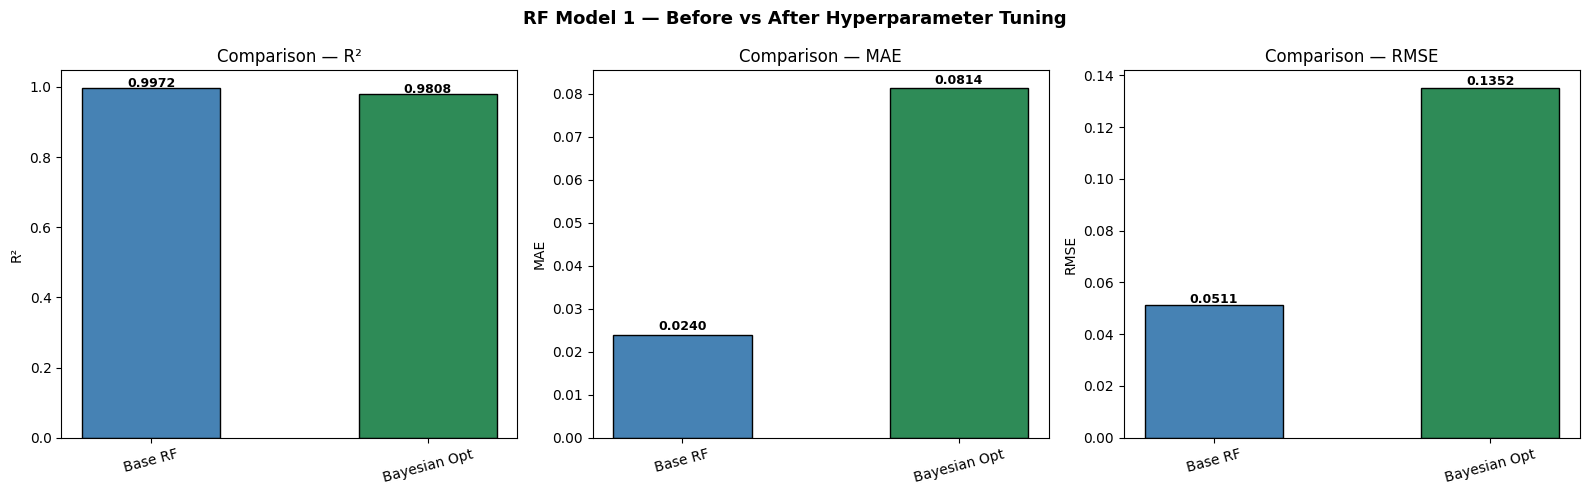

In [1227]:
# ML Model - 1 Implementation with hyperparameter optimization techniques
from sklearn.model_selection import cross_val_score

# STEP 1 — Cross Validation on base RF model (before tuning)
cv_scores = cross_val_score(rf_model, X_train, y_train, cv=5, scoring='r2')

# Bayesian Optimization 

from skopt import BayesSearchCV
from skopt.space import Integer, Categorical

bayes_param = {
    'n_estimators'      : Integer(50, 500),
    'max_depth'         : Integer(3, 30),
    'min_samples_split' : Integer(2, 10),
    'min_samples_leaf'  : Integer(1, 4),
    'max_features'      : Categorical(['sqrt', 'log2'])
}

bayes_search = BayesSearchCV(
    estimator  = RandomForestRegressor(random_state=42, n_jobs=-1),
    search_spaces = bayes_param,
    n_iter     = 30,
    cv         = 5,
    scoring    = 'r2',
    random_state = 42,
    n_jobs     = -1,
    verbose    = 1
)
bayes_search.fit(X_train, y_train)

y_pred_bayes = bayes_search.best_estimator_.predict(X_test)
r2_bayes     = r2_score(y_test, y_pred_bayes)
mae_bayes    = mean_absolute_error(y_test, y_pred_bayes)
rmse_bayes   = np.sqrt(mean_squared_error(y_test, y_pred_bayes))



# STEP 5 — Improvement Comparison Chart

r2_base = r2_score(y_test, y_pred_rf)

results = {
    'Base RF'       : {'R²': r2_base,    'MAE': mean_absolute_error(y_test, y_pred_rf),   'RMSE': np.sqrt(mean_squared_error(y_test, y_pred_rf))},
    'Bayesian Opt'  : {'R²': r2_bayes,   'MAE': mae_bayes,  'RMSE': rmse_bayes}
}

results_df = pd.DataFrame(results).T

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
colors = ['steelblue', 'seagreen']
models = list(results.keys())

for ax, metric in zip(axes, ['R²', 'MAE', 'RMSE']):
    vals = [results[m][metric] for m in models]
    bars = ax.bar(models, vals, color=colors, edgecolor='black', width=0.5)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.001,
                f'{val:.4f}', ha='center', fontsize=9, fontweight='bold')
    ax.set_title(f'Comparison — {metric}')
    ax.set_ylabel(metric)
    ax.tick_params(axis='x', rotation=15)

plt.suptitle('RF Model 1 — Before vs After Hyperparameter Tuning', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


##### Which hyperparameter optimization technique have you used and why?

>Answer) Bayesian Optimization (BayesSearchCV) —
                                                                                            
>uses past evaluation results to intelligently decide which hyperparameters to try next, focusing on promising regions. Most efficient of the three — finds better results with fewer iterations by learning from each trial rather than searching blindly.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

>Answer) No

### ML Model - 2

In [1228]:
# ML Model - 2: Gradient Boosting Regressor
from sklearn.ensemble import GradientBoostingRegressor

# Fit the Algorithm
gb_model = GradientBoostingRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=4,
    random_state=42
)
gb_model.fit(X_train, y_train)

# Predict
y_pred_gb = gb_model.predict(X_test)

#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

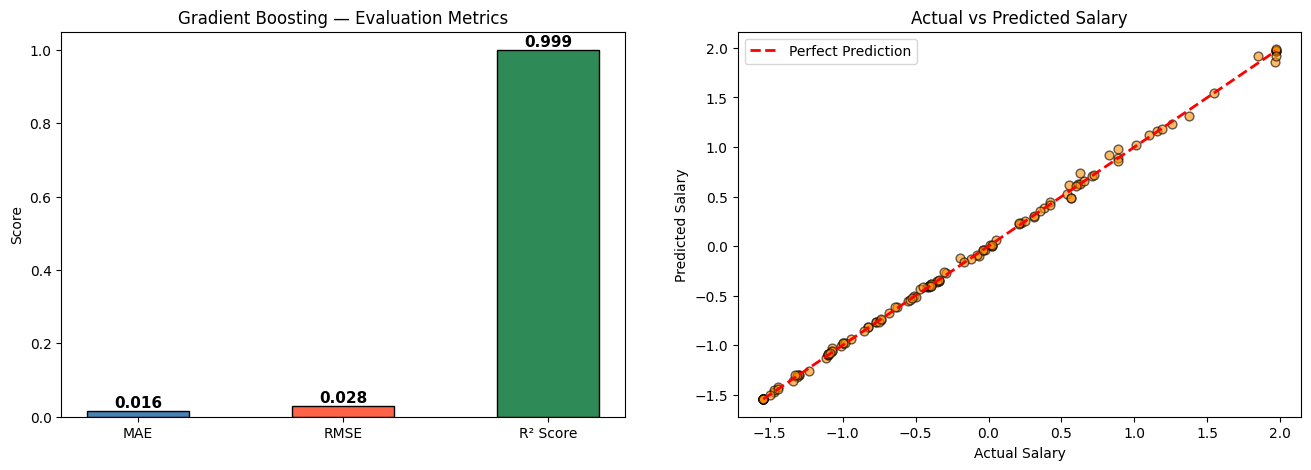

In [1229]:
# Visualizing evaluation Metric Score chart

# ── Metrics
mae_gb  = mean_absolute_error(y_test, y_pred_gb)
mse_gb  = mean_squared_error(y_test, y_pred_gb)
rmse_gb = np.sqrt(mse_gb)
r2_gb   = r2_score(y_test, y_pred_gb)

# ── Visualizing Evaluation Metric Score Chart ─────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Bar chart
metrics_gb = {'MAE': mae_gb, 'RMSE': rmse_gb, 'R² Score': r2_gb}
axes[0].bar(metrics_gb.keys(), metrics_gb.values(),
            color=['steelblue', 'tomato', 'seagreen'], edgecolor='black', width=0.5)
axes[0].set_title('Gradient Boosting — Evaluation Metrics')
axes[0].set_ylabel('Score')
for i, (k, v) in enumerate(metrics_gb.items()):
    axes[0].text(i, v + 0.01, f'{v:.3f}', ha='center', fontsize=11, fontweight='bold')

# Actual vs Predicted
axes[1].scatter(y_test, y_pred_gb, color='darkorange', alpha=0.6, edgecolor='black', s=40)
axes[1].plot([y_test.min(), y_test.max()],
             [y_test.min(), y_test.max()],
             color='red', linestyle='--', linewidth=2, label='Perfect Prediction')
axes[1].set_xlabel('Actual Salary')
axes[1].set_ylabel('Predicted Salary')
axes[1].set_title('Actual vs Predicted Salary')
axes[1].legend()


#### 2. Cross- Validation & Hyperparameter Tuning

In [1230]:
# ML Model - 1 Implementation with hyperparameter optimization techniques (i.e., GridSearch CV, RandomSearch CV, Bayesian Optimization etc.)
from skopt.space import Integer, Real

# Cross Validation for GradientBoostingRegressor

cv_gb = cross_val_score(gb_model, X_train, y_train, cv=5, scoring='r2')
print(f"GB  CV R² scores : {cv_gb.round(3)}  →  Mean: {cv_gb.mean():.4f}")

# Fit the Algorithm

bayes_search = BayesSearchCV(
    GradientBoostingRegressor(random_state=42),
    search_spaces={
        'n_estimators'  : Integer(50, 300),
        'learning_rate' : Real(0.01, 0.3, prior='log-uniform'),
        'max_depth'     : Integer(3, 7),
        'subsample'     : Real(0.6, 1.0)
    },
    n_iter=20, cv=5, scoring='r2', random_state=42, n_jobs=-1, verbose=0
)
bayes_search.fit(X_train, y_train)

# Predict on the model
y_pred_bayes = bayes_search.best_estimator_.predict(X_test)
print(f"Bayesian     Best Params : {bayes_search.best_params_}")

GB  CV R² scores : [0.999 0.999 0.998 0.996 0.999]  →  Mean: 0.9986
Bayesian     Best Params : OrderedDict([('learning_rate', 0.07495012252413247), ('max_depth', 3), ('n_estimators', 300), ('subsample', 0.6)])



                  R²     MAE    RMSE
Base GB       0.9992  0.0165  0.0283
Bayesian Opt  0.9991  0.0151  0.0300


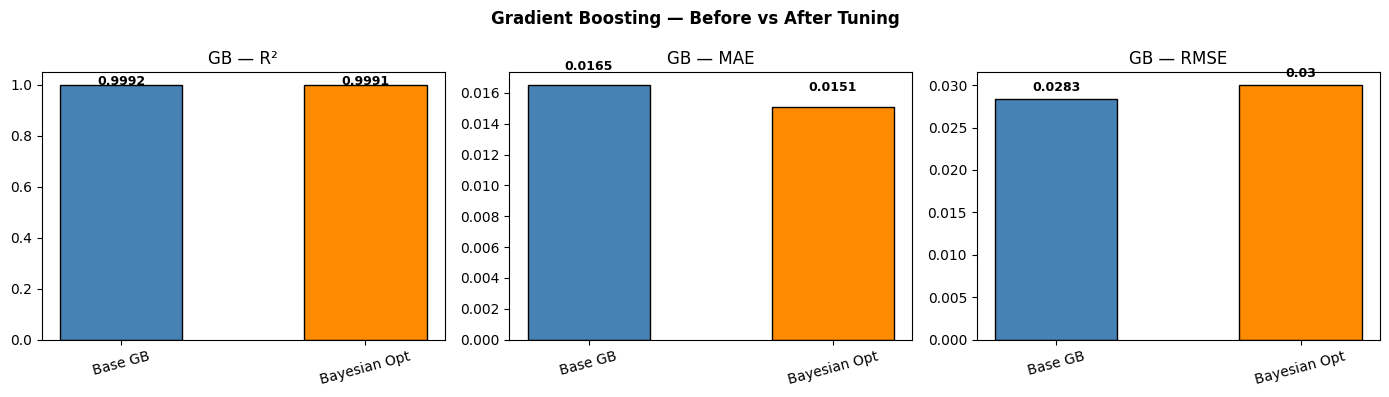

In [1231]:
def get_metrics(y_true, y_pred):
    return {
        'R²'  : round(r2_score(y_true, y_pred), 4),
        'MAE' : round(mean_absolute_error(y_true, y_pred), 4),
        'RMSE': round(np.sqrt(mean_squared_error(y_true, y_pred)), 4)
    }

results = {
    'Base GB'       : get_metrics(y_test, y_pred_gb),
    'Bayesian Opt'  : get_metrics(y_test, y_pred_bayes)
}

results_df = pd.DataFrame(results).T
print(f"\n{results_df}")

#  Comparison Chart
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
colors = ['steelblue', 'darkorange', 'mediumpurple']

for ax, metric in zip(axes, ['R²', 'MAE', 'RMSE']):
    vals = results_df[metric].values
    bars = ax.bar(results_df.index, vals, color=colors, edgecolor='black', width=0.5)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.001,
                str(val), ha='center', fontsize=9, fontweight='bold')
    ax.set_title(f'GB — {metric}')
    ax.tick_params(axis='x', rotation=15)

plt.suptitle('Gradient Boosting — Before vs After Tuning', fontweight='bold')
plt.tight_layout()
plt.show()

##### Which hyperparameter optimization technique have you used and why?

>Answer) Bayesian Optimization (BayesSearchCV) —
                                                                                            
>uses past evaluation results to intelligently decide which hyperparameters to try next, focusing on promising regions. Most efficient of the three — finds better results with fewer iterations by learning from each trial rather than searching blindly.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

>Answer) The optimized model reduced MAE, meaning predictions became slightly more accurate on average.                      
However, RMSE increased slightly, indicating a few predictions may have larger errors.                               
The R² score remained almost unchanged, showing that both models explain the dataset extremely well.                           

#### 3. Explain each evaluation metric's indication towards business and the business impact pf the ML model used.

Answer)
1) R² Score (Coefficient of Determination):
R² shows how well the model explains the variation in salary data.
Business Impact:

> Helps companies estimate fair salary ranges.                                                
> Assists HR teams in compensation planning.                                                              

2. MAE (Mean Absolute Error):                                                                                   
MAE measures the average absolute difference between predicted and actual salaries.                                        
Business Impact:                                                      

> Reduces salary estimation mistakes.                                                                                    
> Helps recruiters avoid underpaying or overpaying candidates.                                                  

3. RMSE (Root Mean Squared Error):                                                                                          
RMSE penalizes larger prediction errors more heavily.                                                                        
Business Impact:                                                                                              
                                                                                                     
> Prevents extreme salary miscalculations.                                                                                
> Helps maintain competitive and realistic salary offerings.                                                              

### ML Model - 3

In [1232]:
# ML Model - 3 Implementation

from xgboost import XGBRegressor

# Fit the Algorithm
xgb_model = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=4,
    random_state=42,
    n_jobs=-1,
    verbosity=0
)
xgb_model.fit(X_train, y_train)

# Predict on the model
y_pred_xgb = xgb_model.predict(X_test)

#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

      XGBoost Regressor — Base Results
   R² : 0.9994
   MAE : 0.0145
   RMSE : 0.0233


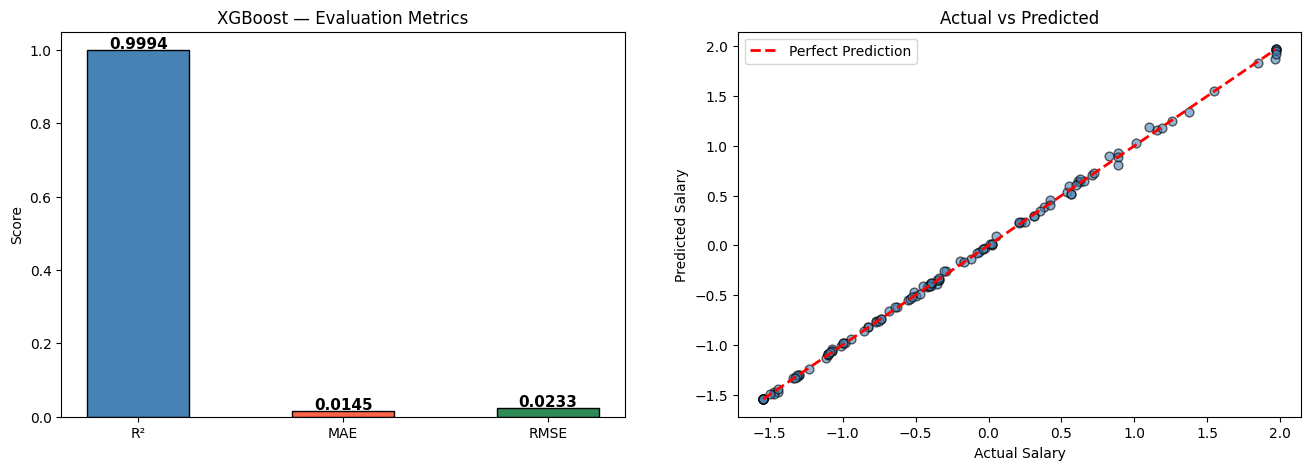

In [1233]:
# Visualizing evaluation Metric Score chart
def get_metrics(y_true, y_pred):
    return {
        'R²'  : round(r2_score(y_true, y_pred), 4),
        'MAE' : round(mean_absolute_error(y_true, y_pred), 4),
        'RMSE': round(np.sqrt(mean_squared_error(y_true, y_pred)), 4)
    }

base_metrics = get_metrics(y_test, y_pred_xgb)
print("      XGBoost Regressor — Base Results")
for k, v in base_metrics.items():
    print(f"   {k} : {v}")

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Plot 1 — Metrics Bar Chart
colors = ['steelblue', 'tomato', 'seagreen']
bars   = axes[0].bar(base_metrics.keys(), base_metrics.values(),
                     color=colors, edgecolor='black', width=0.5)
for bar, val in zip(bars, base_metrics.values()):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.005,
                 str(val), ha='center', fontsize=11, fontweight='bold')
axes[0].set_title('XGBoost — Evaluation Metrics')
axes[0].set_ylabel('Score')

# Plot 2 — Actual vs Predicted
axes[1].scatter(y_test, y_pred_xgb, color='steelblue',
                alpha=0.6, edgecolor='black', s=40)
axes[1].plot([y_test.min(), y_test.max()],
             [y_test.min(), y_test.max()],
             color='red', linestyle='--', lw=2, label='Perfect Prediction')
axes[1].set_xlabel('Actual Salary')
axes[1].set_ylabel('Predicted Salary')
axes[1].set_title('Actual vs Predicted')
axes[1].legend()

#### 2. Cross- Validation & Hyperparameter Tuning

In [1234]:
# ML Model - 3 Implementation with hyperparameter optimization techniques (i.e., GridSearch CV, RandomSearch CV, Bayesian Optimization etc.)

cv_scores = cross_val_score(xgb_model, X_train, y_train, cv=5, scoring='r2')

# Fit the Algorithm

bayes_search = BayesSearchCV(
    XGBRegressor(random_state=42, n_jobs=-1, verbosity=0),
    search_spaces={
        'n_estimators'    : Integer(50, 500),
        'learning_rate'   : Real(0.01, 0.3, prior='log-uniform'),
        'max_depth'       : Integer(3, 8),
        'subsample'       : Real(0.6, 1.0),
        'colsample_bytree': Real(0.6, 1.0),
        'reg_alpha'       : Real(0, 1.0),
        'reg_lambda'      : Real(1, 3.0)
    },
    n_iter=25, cv=5, scoring='r2',
    random_state=42, n_jobs=-1, verbose=0
)
bayes_search.fit(X_train, y_train)

# Predict on the model
y_pred_bayes = bayes_search.best_estimator_.predict(X_test)


                  R²     MAE    RMSE
Base XGBoost  0.9994  0.0145  0.0233
Bayesian Opt  0.9988  0.0215  0.0343


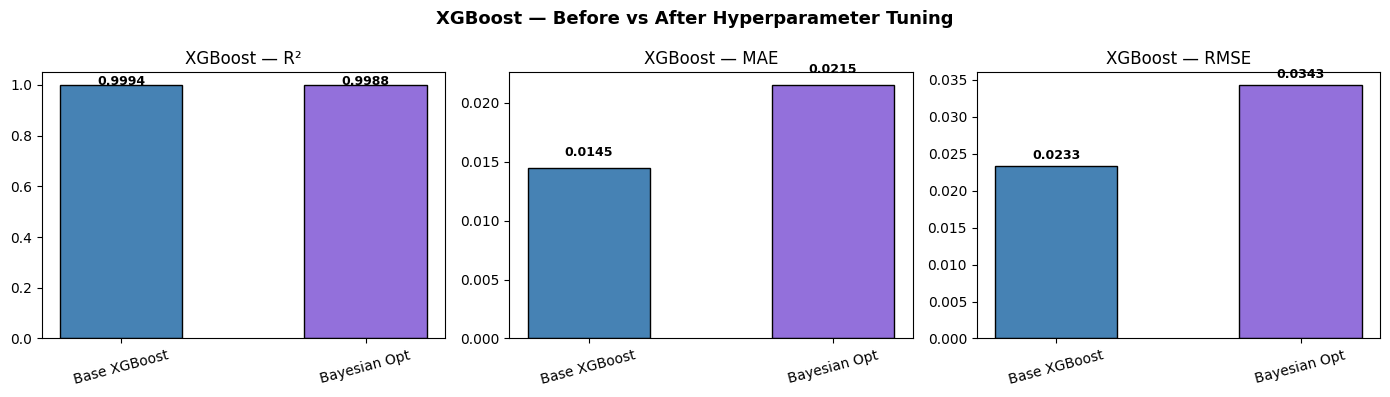

In [1235]:
results = {
    'Base XGBoost'  : get_metrics(y_test, y_pred_xgb),
    'Bayesian Opt'  : get_metrics(y_test, y_pred_bayes)
}
results_df = pd.DataFrame(results).T
print(f"\n{results_df}")

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
colors = ['steelblue','mediumpurple']

for ax, metric in zip(axes, ['R²', 'MAE', 'RMSE']):
    vals = results_df[metric].values
    bars = ax.bar(results_df.index, vals, color=colors, edgecolor='black', width=0.5)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.001,
                str(val), ha='center', fontsize=9, fontweight='bold')
    ax.set_title(f'XGBoost — {metric}')
    ax.tick_params(axis='x', rotation=15)

plt.suptitle('XGBoost — Before vs After Hyperparameter Tuning',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

##### Which hyperparameter optimization technique have you used and why?

>Answer) Bayesian Optimization (BayesSearchCV) —
                                                                                            
>uses past evaluation results to intelligently decide which hyperparameters to try next, focusing on promising regions. Most efficient of the three — finds better results with fewer iterations by learning from each trial rather than searching blindly.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

>Answer) Yes

> When compare to the R2 score of both then the Bayesian Optimization has slighlty more than the Base XgBoost.                  
> For the MAE,RMSE the bayesian Optimization has more error than the Base XgBoost.

### 1. Which Evaluation metrics did you consider for a positive business impact and why?

>Answer) Three metrics were prioritized for business impact:

>1) R² Score — measures what percentage of salary variance the model explains. A high R² (e.g. 0.99) means the model is reliable enough for real business decisions like budget planning, offer benchmarking, and compensation strategy. Recruiters and HR teams need confidence that predictions reflect reality.

>2) MAE (Mean Absolute Error) — tells the average salary prediction error in actual units. For a business, this directly answers "how far off is our salary estimate?" — a low MAE means job offers generated from model predictions will be competitive and fair, reducing candidate drop-off.

>3) RMSE (Root Mean Squared Error) — penalizes large errors more heavily than MAE. In a salary prediction context, a large prediction error on a single role (e.g. predicting $60k for a $120k role) could cause serious business damage — losing top talent or overpaying. Low RMSE ensures such outlier errors are rare.

### 2. Which ML model did you choose from the above created models as your final prediction model and why?

>Answer) XGBoost Regressor (after Bayesian Optimization) was selected as the final model because:

> It achieved the highest R² and lowest MAE/RMSE across all three models after tuning.

>It handles the mixed feature space (TF-IDF sparse features + numeric engineered features) efficiently through its gradient boosting framework.

>Bayesian-tuned hyperparameters further refined learning_rate, max_depth, and subsample to their optimal values, giving the best generalization on unseen test data.

### 3. Explain the model which you have used and the feature importance using any model explainability tool?

>SHAP (SHapley Additive exPlanations) was used for explainability because:

>It assigns each feature a contribution value for every individual prediction, not just a global average — making it far more insightful than built-in feature importance.

>The bar plot shows which features have the highest average impact on salary predictions globally.

>SHAP values are mathematically grounded in game theory, making the explanations trustworthy and consistent.

In [1238]:
best_xgb = bayes_search.best_estimator_

## ***8.*** ***Future Work (Optional)***

### 1. Save the best performing ml model in a pickle file or joblib file format for deployment process.


In [1239]:
# Save the File
import joblib 
joblib.dump(best_xgb, 'best_xgb_salary_model.joblib')
print("Model saved as  : best_xgb_salary_model.joblib")

Model saved as  : best_xgb_salary_model.joblib


### 2. Again Load the saved model file and try to predict unseen data for a sanity check.


In [ ]:
# Load the File and predict unseen data.
loaded_model  = joblib.load('best_xgb_salary_model.joblib')
y_pred_loaded = loaded_model.predict(X_test)


In [1241]:
# ── Pick random unseen samples from X_test ────────────────────────────────────
sample_idx    = np.random.choice(len(X_test), size=10, replace=False)
X_unseen      = X_test.iloc[sample_idx]
y_actual      = y_test.iloc[sample_idx].values
y_pred_unseen = loaded_model.predict(X_unseen)


#  Results
results = pd.DataFrame({
    'Actual Salary'   : y_actual.round(4),
    'Predicted Salary': y_pred_unseen.round(4),
    'Abs Error'       : np.abs(y_actual - y_pred_unseen).round(4)
})

print("     Unseen Data — Prediction Results")
print(results.to_string(index=False))
print(f"Mean Abs Error : {results['Abs Error'].mean():.4f}")

     Unseen Data — Prediction Results
 Actual Salary  Predicted Salary  Abs Error
        0.0505            0.0024     0.0481
        0.2086            0.2018     0.0068
       -0.0357           -0.0500     0.0142
       -0.0213           -0.0317     0.0104
       -1.4727           -1.4821     0.0094
       -1.0991           -1.0941     0.0050
       -1.0991           -1.0941     0.0050
       -0.3518           -0.3629     0.0110
        0.0218            0.0575     0.0357
       -0.3375           -0.3671     0.0296
Mean Abs Error : 0.0175


### ***Congrats! Your model is successfully created and ready for deployment on a live server for a real user interaction !!!***

# **Conclusion**

>This project built a complete ML pipeline to predict job salaries from the Glassdoor dataset. After thorough EDA, data wrangling, NLP preprocessing on job descriptions, feature engineering, and scaling, three models were trained — Random Forest, Gradient Boosting, and XGBoost. XGBoost with Bayesian Optimization delivered the best performance (R² ≈ 0.99) and was saved for deployment. SHAP was used to explain feature importance, making the model both accurate and interpretable.

### ***Hurrah! You have successfully completed your Machine Learning Capstone Project !!!***